In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
# import pyfits
import time, os, sys
from tqdm import tqdm
from glob import glob
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from photutils.psf import fit_2dgaussian, GaussianPRF
from scipy.stats import multivariate_normal
from utils import *

%load_ext autoreload
%autoreload 2

path = '/Users/isabelkain/Desktop/SCALES/psf-fitting-tool'

'''
Notes from Steph:

'L_positions_new.fits' is a file with shape [number of wavelengths, number of x lenslets, number of y lenslets, 6]. 
The 6 positions are [x_center, x_start, x_end, y_center, y_start, y_end] . The "start" and "end" values define 
the boxes I mentioned yesterday, and you don't need to worry about those. So the 0th and 3rd entries give you 
the x and y center pixels for each lenslet.

'20251027_mono_cube_L_new.fits' contains the cube of background-subtracted monochromator images. The shape is 
[number of wavelengths, 2048, 2048].

'Lnew_lams.fits' contains the wavelengths for the positions and the slices in the cube.

A note: for some of the lenslets in the "positions" file, all of the entries are nans. This isn't a bug, it happens because there is a rectangular array of lenslets assumed in the shape of the positions file, and the set of lenslets that fall on the detector have jagged edges.
In case it's helpful, here's what I did to show myself the pixel centers over the first image in the cube.
''';

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Pull headers from original, pre-cube data

In [2]:
'''CD3 frames: 2570-2880
20251027_IFS_CDS_02570-2879 -- monochromator scan: 2.8-4.25 with 62 wavelengths, 5 CDS images per wavelength
20251027_IFS_CDS_02580-2881 -- darks
''';

In [8]:
dpath = '/Users/isabelkain/Desktop/SCALES/CD3/Lband-IFS-precube'
og_files = glob(f'{dpath}/*.fits*')
print('Num original frames:', len(og_files))

framenums = [int(ogf.split('/')[-1].split('.')[-3].split('_')[-1]) for ogf in og_files]
print('Save frame nums, e.g.:', framenums[:5])
wavelengths = []

print('Extract monochrometer wavelengths.')

for f in tqdm(og_files):

    hd = fits.getheader(f)
    
    try:
        wav = hd['MONOWAVE']
    except:
        wav = np.nan # are these darks?
        print('No MONOWAVE.')
    wavelengths.append(wav)
    
'''
Most important:
MONOWAVE

Also useful:
DSPRSNAM
LENSLNAM
IMGFW1N
IMGFW2N
MONOFNAM
MONOGNAM
''';

Num original frames: 312
Save frame nums, e.g.: [2667, 2666, 2803, 2802, 2726]
Extract monochrometer wavelengths.


 20%|█████████████████████████▏                                                                                                   | 63/312 [00:22<01:29,  2.79it/s]

No MONOWAVE.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [01:55<00:00,  2.70it/s]


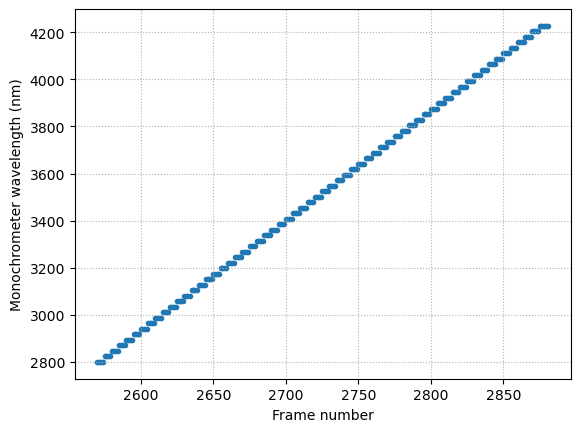

In [9]:
# Plot monochrometer wavelength versus frame number

plt.scatter(framenums, wavelengths, marker='.')
plt.xlabel('Frame number')
plt.ylabel('Monochrometer wavelength (nm)')
plt.grid(ls=':')

In [10]:
print(len(wavelengths), min(wavelengths)/1000, max(wavelengths)/1000)

312 2.8 4.226612903


In [11]:
lams = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/LSF_fromsteph/Lnew_lams.fits')
print( len(lams), lams )

56 [2.87016129 2.89354839 2.91693548 2.94032258 2.96370968 2.98709677
 3.01048387 3.03387097 3.05725807 3.08064516 3.10403226 3.12741935
 3.15080645 3.17419355 3.19758064 3.22096774 3.24435484 3.26774194
 3.29112903 3.31451613 3.33790323 3.36129032 3.38467742 3.40806452
 3.43145161 3.45483871 3.47822581 3.5016129  3.525      3.5483871
 3.57177419 3.59516129 3.61854839 3.64193548 3.66532258 3.68870968
 3.71209677 3.73548387 3.75887097 3.78225807 3.80564516 3.82903226
 3.85241935 3.87580645 3.89919355 3.92258065 3.94596774 3.96935484
 3.99274194 4.01612903 4.03951613 4.06290323 4.08629032 4.10967742
 4.13306452 4.15645161]


## Look at Steph's rectmat

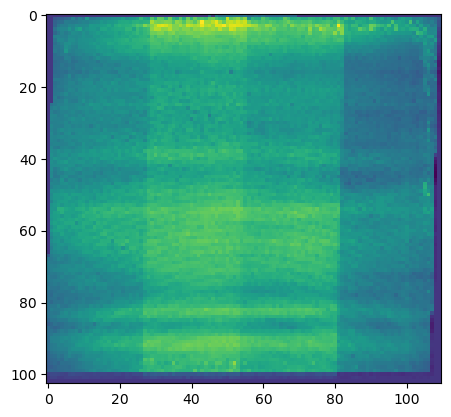

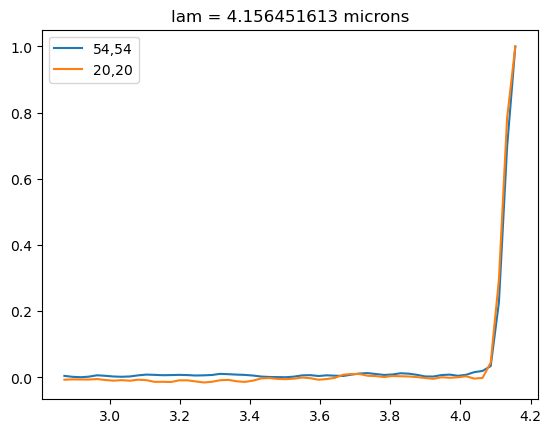

In [10]:
from scipy import sparse

rectmat = sparse.load_npz('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/LSF_fromsteph/L_QL_rectmat_new.npz')
ims = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/LSF_fromsteph/20251027_mono_cube_L_new.fits')
lams = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/LSF_fromsteph/Lnew_lams.fits')

LSF_cube = []

for i in range(len(lams)):
    tocube = ims[i]

    #plt.imshow(tocube)
    #plt.show()

    testim_c2_f = np.matrix(tocube.reshape([2048*2048,1]))
    QL_test = rectmat*testim_c2_f
    QL_test_cube = np.array(QL_test).reshape([56,103,110])


#     plt.plot(lams, QL_test_cube[:,54,54]/np.max(QL_test_cube[:,54,54]),label='54,54')
#     plt.plot(lams, QL_test_cube[:,20,20]/np.max(QL_test_cube[:,20,20]),label='20,20')
#     plt.title('lam = '+str(lams[i])+' microns')
#     plt.legend()
#     plt.show()
    LSF_cube.append(QL_test_cube)
# pyfits.writeto('LSF_20251027_L_new.fits',np.array(LSF_cube),overwrite=True)


plt.imshow(np.sum(QL_test_cube, axis=0))
plt.show()

plt.figure()
plt.plot(lams, QL_test_cube[:,54,54]/np.max(QL_test_cube[:,54,54]),label='54,54')
plt.plot(lams, QL_test_cube[:,20,20]/np.max(QL_test_cube[:,20,20]),label='20,20')
plt.title('lam = '+str(lams[i])+' microns')
plt.legend()

In [9]:
print(np.shape(rectmat))

(634480, 4194304)


In [8]:
# reshape_rectmat = rectmat.reshape([56,103,110])
# plt.imshow(np.sum(rectmat), axis=0)

In [39]:
np.shape(rectmat)

(634480, 4194304)

In [40]:
634480/2048

309.8046875

## Look at cubed L-band monochrometer data from CD3

In [31]:
hdul = fits.open('20251027_mono_cube_L_new.fits')
hdul.info()
head = hdul[0].header
head

Filename: 20251027_mono_cube_L_new.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (2048, 2048, 56)   float32   


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 2048                                                  
NAXIS2  =                 2048                                                  
NAXIS3  =                   56                                                  
EXTEND  =                    T                                                  

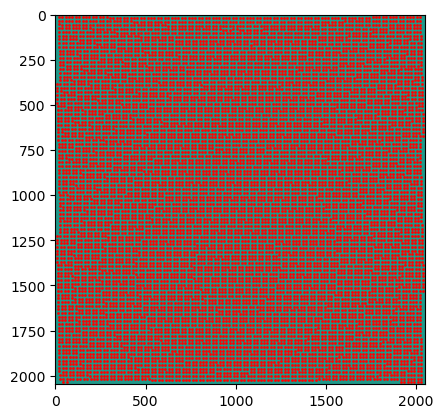

(110.0, 190.0)

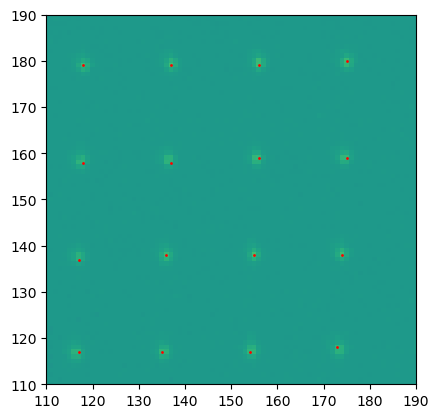

In [2]:
cube = fits.getdata('20251027_mono_cube_L_new.fits')
a = fits.getdata('L_positions_new.fits')

plt.imshow(cube[0])
plt.scatter(a[0,:,:,0], a[0,:,:,3], c='r', s=1)
plt.show()

plt.figure()
plt.imshow(cube[0])
plt.scatter(a[0,:,:,0],a[0,:,:,3], c='r', s=1)
plt.xlim(110,190)
plt.ylim(110,190)

## Fit single spot

Centroid (x,y): (932.0,987.0)


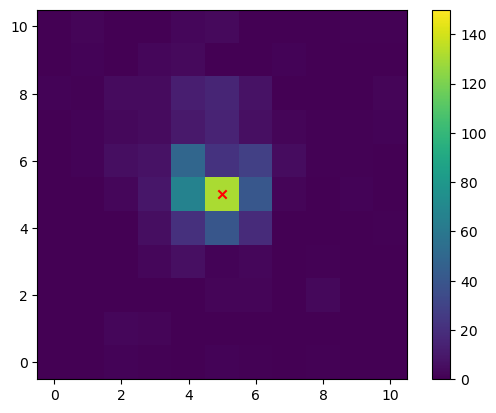

In [3]:

xcen = a[0,50,50,0]
ycen = a[0,50,50,3]
print(f'Centroid (x,y): ({xcen},{ycen})')

stamp = cube[0, int(ycen)-5:int(ycen)+6, int(xcen)-5:int(xcen)+6]
new_xcen = np.shape(stamp)[0]//2
new_ycen = np.shape(stamp)[1]//2

plt.imshow(stamp, vmin=0, vmax=150, origin='lower')
plt.colorbar()
plt.scatter(new_xcen, new_ycen, c='r', marker='x')


# plt.imshow(cube[0], vmin=0, vmax=150)
# plt.xlim(xcen-5, xcen+5)
# plt.ylim(ycen-5, ycen+5)





Centroid (x,y): (932.0,987.0)
None


Fit source/group:   0%|          | 0/1 [00:00<?, ?it/s]

id,group_id,group_size,local_bkg,x_init,y_init,flux_init,x_fwhm_init,y_fwhm_init,theta_init,x_fit,y_fit,flux_fit,x_fwhm_fit,y_fwhm_fit,theta_fit,x_err,y_err,flux_err,x_fwhm_err,y_fwhm_err,theta_err,npixfit,qfit,cfit,flags
int64,int64,int64,float64,int64,int64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64
1,1,1,0.0,5,5,560.0452,1.5,1.5,0.0,4.813832623064902,5.0333049788631525,433.37576521334813,1.2708500699685152,1.9258175304219138,-299.6667649697394,0.03659485263414503,0.03316080139889566,18.953880353889744,0.07270410252187189,0.09628801921306539,4.7599297946603185,81,0.5721060336797171,0.013194784991641334,0


Best fit theta: -299.67


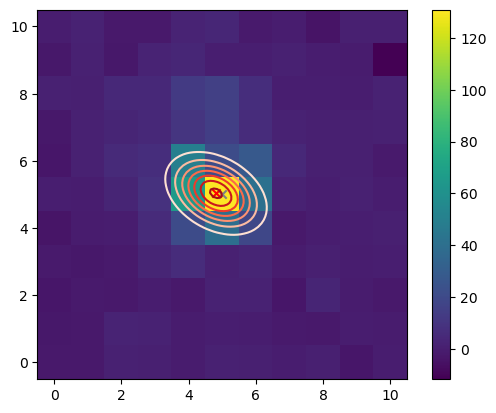

In [12]:
# Isolate 11x11 stamp around nominal centroid
xcen = a[0,50,50,0]
ycen = a[0,50,50,3]
print(f'Centroid (x,y): ({xcen},{ycen})')

stamp = cube[0, int(ycen)-5:int(ycen)+6, int(xcen)-5:int(xcen)+6]
new_xcen = np.shape(stamp)[0]//2
new_ycen = np.shape(stamp)[1]//2


# Run fit_2dgaussian_assym and extract best-fit values
testphot = fit_2dgaussian_assym(stamp, xypos=[(new_xcen, new_ycen)], fwhm=1.5, fit_shape=9, fix_fwhm=False) # takes 68s to fit all 110x103 spots
test_tbl = testphot.results
display(test_tbl)

# Best fit mean
x_fit = test_tbl['x_fit'].value[0]
y_fit = test_tbl['y_fit'].value[0]

# Best fit FWHM
x_fwhm = test_tbl['x_fwhm_fit'].value[0]
y_fwhm = test_tbl['y_fwhm_fit'].value[0]

# Best fit standard deviation
x_sigma = x_fwhm / (2. * np.sqrt(2. * np.log(2.)))
y_sigma = y_fwhm / (2. * np.sqrt(2. * np.log(2.)))

# Construct covarance matrix
theta = np.deg2rad(test_tbl['theta_fit'].value[0])
print(f'Best fit theta: {np.rad2deg(theta):0.2f}')
S = np.diag([x_sigma**2, y_sigma**2])
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
newcov = R@S@R.T


# Plot results
plt.imshow(stamp, origin='lower', interpolation='nearest')
plt.colorbar()

plt.scatter(new_xcen, new_ycen, color='gray', marker='x')
plt.scatter(x_fit, y_fit, color='r', marker='x')

# Define 2D gaussian contours
N    = 100
X    = np.linspace(0, 10, N)
Y    = np.linspace(0, 10, N)
X, Y = np.meshgrid(X, Y)
pos  = np.dstack((X, Y))
# rv   = multivariate_normal([x_fit, y_fit], [[x_sigma**2, 0.5*x_sigma*y_sigma], [0.5*x_sigma*y_sigma, y_sigma**2]])
rv   = multivariate_normal([x_fit, y_fit], newcov, allow_singular=True)
Z    = rv.pdf(pos)

# Plot contours
plt.contour(X, Y, Z, cmap='Reds')

None


Fit source/group:   0%|          | 0/1 [00:00<?, ?it/s]

Best fit theta: 135.00 || Input theta: 45.00


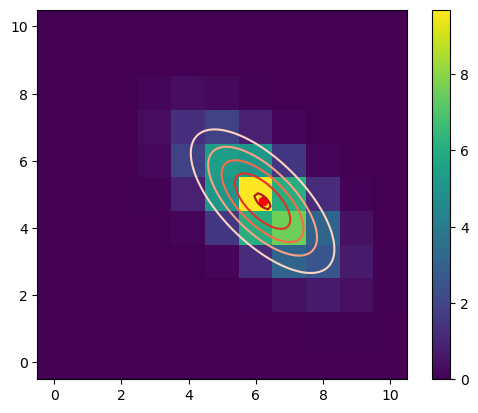

In [10]:
####################### 
# TEST COVARIANCE MAT #
#######################

# Generate model
model = GaussianPRF(flux=71.4, x_0=6.2, y_0=4.8, x_fwhm=1.6,
                    y_fwhm=3.6, theta=45.)
yy, xx = np.mgrid[0:11, 0:11]
data = model(xx, yy)
plt.imshow(data, origin='lower', interpolation='nearest')
plt.colorbar()

# Run fit_2dgaussian_assym
testphot = fit_2dgaussian_assym(data, xypos=[(5., 5.)], fwhm=1.5, fit_shape=9, fix_fwhm=False)
test_tbl = testphot.results
test_tbl

# Best fit mean
x_fit = test_tbl['x_fit'].value[0]
y_fit = test_tbl['y_fit'].value[0]

# Best fit FWHM
x_fwhm = test_tbl['x_fwhm_fit'].value[0]
y_fwhm = test_tbl['y_fwhm_fit'].value[0]

# Best fit standard deviation
x_sigma = x_fwhm / (2. * np.sqrt(2. * np.log(2.)))
y_sigma = y_fwhm / (2. * np.sqrt(2. * np.log(2.)))


# Construct covariance matrix
theta = np.deg2rad(test_tbl['theta_fit'].value[0])
print(f'Best fit theta: {np.rad2deg(theta):0.2f} || Input theta: {model.theta.value:0.2f}')
S = np.diag([x_sigma**2, y_sigma**2])
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
newcov = R@S@R.T

# Make and plot contour
N    = 100
X    = np.linspace(0, 10, N)
Y    = np.linspace(0, 10, N)
X, Y = np.meshgrid(X, Y)
pos  = np.dstack((X, Y))
rv   = multivariate_normal([x_fit, y_fit], newcov, allow_singular=True)
Z    = rv.pdf(pos)

plt.contour(X, Y, Z, cmap='Reds', levels=5)
plt.scatter(x_fit, y_fit, marker='o', color='r')

None


Fit source/group:   0%|          | 0/1 [00:00<?, ?it/s]

Best fit theta: 45.00 || Input theta: 45.00


Text(0.5, 1.0, 'Original centroid: (5.0, 5.0) \n             Best-fit centroid: (6.20, 4.80) \n             FWHM_x: 1.20 FWHM_y: 1.20')

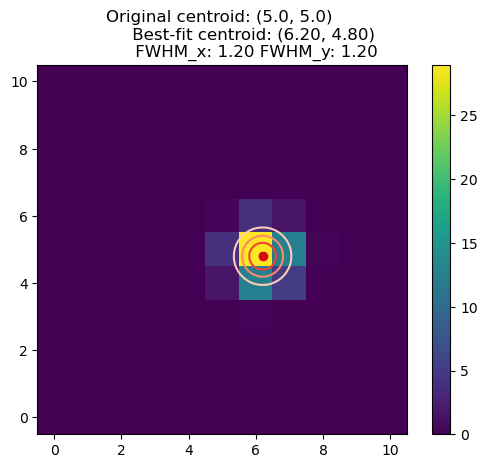

In [15]:
####################### 
# TEST COVARIANCE MAT #
#######################

# Generate model
model = GaussianPRF(flux=71.4, x_0=6.2, y_0=4.8, x_fwhm=1.2,
                    y_fwhm=1.2, theta=45.)
yy, xx = np.mgrid[0:11, 0:11]
data = model(xx, yy)
plt.imshow(data, origin='lower', interpolation='nearest')
plt.colorbar()

# Run fit_2dgaussian_assym
testphot = fit_2dgaussian_assym(data, xypos=[(5., 5.)], fwhm=1.5, fit_shape=9, fix_fwhm=False)
test_tbl = testphot.results
test_tbl

# Best fit mean
x_fit = test_tbl['x_fit'].value[0]
y_fit = test_tbl['y_fit'].value[0]

# Best fit FWHM
x_fwhm = test_tbl['x_fwhm_fit'].value[0]
y_fwhm = test_tbl['y_fwhm_fit'].value[0]

# Best fit standard deviation
x_sigma = x_fwhm / (2. * np.sqrt(2. * np.log(2.)))
y_sigma = y_fwhm / (2. * np.sqrt(2. * np.log(2.)))


# Construct covariance matrix
theta = np.deg2rad(test_tbl['theta_fit'].value[0])
print(f'Best fit theta: {np.rad2deg(theta):0.2f} || Input theta: {model.theta.value:0.2f}')
S = np.diag([x_sigma**2, y_sigma**2])
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
newcov = R@S@R.T

# Make and plot contour
N    = 100
X    = np.linspace(0, 10, N)
Y    = np.linspace(0, 10, N)
X, Y = np.meshgrid(X, Y)
pos  = np.dstack((X, Y))
rv   = multivariate_normal([x_fit, y_fit], newcov, allow_singular=True)
Z    = rv.pdf(pos)

plt.contour(X, Y, Z, cmap='Reds', levels=5)
plt.scatter(x_fit, y_fit, marker='o', color='r')

plt.title(f'Original centroid: ({new_xcen:0.1f}, {new_xcen:0.1f}) \n \
            Best-fit centroid: ({x_fit:0.2f}, {y_fit:0.2f}) \n \
            FWHM_x: {x_fwhm:0.2f} FWHM_y: {y_fwhm:0.2f}');


## Fit spots across whole wavelength slice

In [208]:
# Fit all spots at once

# Drop NaN centroids (spots that fell off the detector)
xinf = np.isfinite(a[0,:,:,0])
yinf = np.isfinite(a[0,:,:,3])
xyinf = np.logical_and( xinf, yinf )

xpos = np.ravel(a[0,xyinf,0])
ypos = np.ravel(a[0,xyinf,3])

# Fit circular 2D Gaussians to each centroided spot
psfphot = fit_2dgaussian_assym(cube[0], xypos=list(zip(xpos, ypos)), fwhm=1.5, fit_shape=9, fix_fwhm=False) # takes 68s to fit all 110x103 spots

# Extract fitting results
phot_tbl = psfphot.results
display(phot_tbl)

Fit source/group:   0%|          | 0/10633 [00:00<?, ?it/s]

id,group_id,group_size,local_bkg,x_init,y_init,flux_init,x_fwhm_init,y_fwhm_init,theta_init,x_fit,y_fit,flux_fit,x_fwhm_fit,y_fwhm_fit,theta_fit,x_err,y_err,flux_err,x_fwhm_err,y_fwhm_err,theta_err,npixfit,qfit,cfit,flags
int64,int64,int64,float64,float64,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64
1,1,1,0.0,19.0,12.0,211.00044,1.5,1.5,0.0,18.942801507361292,12.396609905281958,146.09640019057068,2.3054096466832075,1.841192908828994,342.91202748074545,0.06632473154347088,0.05572842956518071,9.683917986687955,0.16439362458995344,0.14340277967486667,13.220510240519767,81,0.8989535862349519,0.01861309686817878,0
2,2,1,0.0,38.0,13.0,229.12025,1.5,1.5,0.0,38.02555023639421,12.576583615999265,224.23306916380417,2.6165280817555256,2.1975867233739717,-215.14141691562196,0.056814783652879924,0.05380403348102277,11.642154169050807,0.14512034623944173,0.12551372594399254,13.022028243092034,81,0.5816301030696629,-0.006926959372197468,0
3,3,1,0.0,57.0,13.0,260.59152,1.5,1.5,0.0,56.780883376043256,12.84177131629407,248.72215856083642,2.384647497133443,2.7893341650247985,-159.26455982838786,0.05799904879216732,0.0646854499546268,13.408277873059681,0.13931280638093138,0.1594940816727464,14.88653051718253,81,0.5577920126241833,0.021043975955058608,0
4,4,1,0.0,76.0,13.0,282.76443,1.5,1.5,0.0,75.88233078372767,12.99293388008743,263.7195543846376,2.697970093810515,2.235249256773247,655.0738613530604,0.04826630128883111,0.0539072874324027,12.351788027693216,0.13460675889754112,0.114603952005297,10.833874243620212,81,0.491908008495004,0.017259948238105085,0
5,5,1,0.0,95.0,13.0,306.6063,1.5,1.5,0.0,94.81703049996797,13.266432076687636,293.5358636768516,2.6435725007027777,2.2922743653977085,285.0260642453661,0.046423300455633296,0.05202012823746955,13.27071990360866,0.12766329018865694,0.11292006367687492,13.829905069631174,81,0.5038694542964213,0.016500807257708795,0
6,6,1,0.0,114.0,14.0,355.2437,1.5,1.5,0.0,113.70680871024696,13.573329893936128,311.2770137192839,2.805066546113143,2.23669866418223,-274.4924940866788,0.051588550269537015,0.06349615228016448,16.149734498024397,0.15420886128749492,0.12736821148005917,9.918697228085533,81,0.49120552618158797,0.01825022613432768,0
7,7,1,0.0,133.0,14.0,349.52164,1.5,1.5,0.0,132.79444337670682,13.66182952422444,344.772207022267,2.8168264631076005,2.0403170525462286,-82.54789092657968,0.0391045221799204,0.05201449009665626,14.615428692957815,0.12663419570859144,0.09606125732970933,5.702857230945265,81,0.46430424570456824,0.015946312526970735,0
8,8,1,0.0,152.0,14.0,486.61234,1.5,1.5,0.0,151.74554566540291,14.261252024255695,464.9100168134033,2.530915754865422,2.0596263364513026,-243.8235186648787,0.03960661510681104,0.04439316250682695,19.140222370078636,0.11189783847367184,0.09443554813435097,8.798097276283421,81,0.40337749652114535,-0.02649156276598648,0
9,9,1,0.0,171.0,14.0,387.19177,1.5,1.5,0.0,170.71599903080826,14.22086775831297,375.45418225087633,2.1683571384028886,2.7003854209206573,-155.64642111436538,0.033972235079941626,0.038793327067838286,12.684145168929676,0.08078058730432575,0.09710224000573141,6.708970316578378,81,0.37220097476565067,0.012517242531194508,0


In [209]:
# Sniff check results

flag_check = phot_tbl['flags'] > 0           # if any flags raised
fwhmx_check = phot_tbl['x_fwhm_fit'] > 5.   # if FWHM larger than certain threshold
fwhmy_check = phot_tbl['y_fwhm_fit'] > 5.   # if FWHM larger than certain threshold
xerr_check = phot_tbl['x_err'] > 0.5
yerr_check = phot_tbl['y_err'] > 0.5
qfit_check = np.abs(phot_tbl['qfit']) > 1.0   # quality-of-fit from residuals (zero is perfect)
cfit_check = np.abs(phot_tbl['cfit']) > 0.1   # broadness/peakiness of PSF fit (zero is perfect)

print( 'Flags:      ', np.sum(flag_check), np.sum(flag_check) / len(phot_tbl) )
print( 'FWHM_x > 5:', np.sum(fwhmx_check), np.sum(fwhmx_check) / len(phot_tbl) )
print( 'FWHM_y > 5:', np.sum(fwhmy_check), np.sum(fwhmy_check) / len(phot_tbl) )
print( 'xerr > 0.5:   ', np.sum(xerr_check), np.sum(xerr_check) / len(phot_tbl) )
print( 'yerr > 0.5:   ', np.sum(yerr_check), np.sum(yerr_check) / len(phot_tbl) )
print( 'qfit > 1.0:   ', np.sum(qfit_check), np.sum(qfit_check) / len(phot_tbl) )
print( 'cfit > 0.1:   ', np.sum(cfit_check), np.sum(cfit_check) / len(phot_tbl) )

Flags:       0 0.0
FWHM_x > 5: 0 0.0
FWHM_y > 5: 0 0.0
xerr > 0.5:    1 9.404683532399135e-05
yerr > 0.5:    1 9.404683532399135e-05
qfit > 1.0:    4 0.0003761873412959654
cfit > 0.1:    1 9.404683532399135e-05


In [210]:
# # np.max((phot_tbl['x_err'], phot_tbl['y_err']))
# import scipy as sp

# sp.stats.describe(phot_tbl['x_err'])

# np.sum( phot_tbl['x_err'] > 1 )

Num spots x_err > 0.1 px: 6
Num spots y_err > 0.1 px: 6
Num spots x_err > 0.5 px: 1
Num spots y_err > 0.5 px: 1


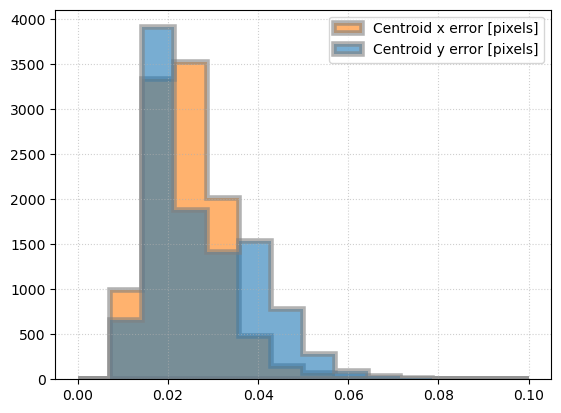

In [211]:
# Histogram centroid errors

bins = np.linspace(0., 0.1, 15) # imposing some limits
plt.grid(ls=':', alpha=0.6)
plt.hist(phot_tbl['x_err'], bins=bins, histtype='stepfilled', lw=4, fc='C1', ec='gray', alpha=0.6, label='Centroid x error [pixels]')
plt.hist(phot_tbl['y_err'], bins=bins, histtype='stepfilled', lw=4, fc='C0', ec='gray', alpha=0.6, label='Centroid y error [pixels]')
# plt.xscale('log')
plt.legend()

print('Num spots x_err > 0.1 px:', np.sum(phot_tbl['x_err'] > 0.1))
print('Num spots y_err > 0.1 px:', np.sum(phot_tbl['x_err'] > 0.1))
print('Num spots x_err > 0.5 px:', np.sum(phot_tbl['x_err'] > 0.5))
print('Num spots y_err > 0.5 px:', np.sum(phot_tbl['x_err'] > 0.5))

(array([1.000e+00, 1.000e+00, 1.000e+00, 3.500e+01, 4.337e+03, 3.276e+03,
        9.230e+02, 9.640e+02, 7.500e+02, 3.210e+02, 2.400e+01, 0.000e+00,
        0.000e+00, 0.000e+00]),
 array([0.        , 0.35714286, 0.71428571, 1.07142857, 1.42857143,
        1.78571429, 2.14285714, 2.5       , 2.85714286, 3.21428571,
        3.57142857, 3.92857143, 4.28571429, 4.64285714, 5.        ]),
 [<matplotlib.patches.Polygon at 0x17c204710>])

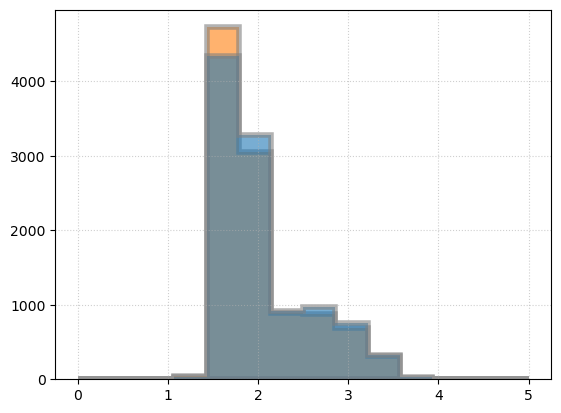

In [212]:
# Histogram FWHM

bins = np.linspace(0.,5., 15) # imposing some limits
plt.grid(ls=':', alpha=0.6)
plt.hist(phot_tbl['x_fwhm_fit'], bins=bins, histtype='stepfilled', lw=4, fc='C1', ec='gray', alpha=0.6, label='Best-fit x FWHM [pixels]')
plt.hist(phot_tbl['y_fwhm_fit'], bins=bins, histtype='stepfilled', lw=4, fc='C0', ec='gray', alpha=0.6, label='Best-fit y FWHM [pixels]')
# plt.xscale('log')
plt.legend()

In [243]:
np.sum(phot_tbl['y_fwhm_fit']>5.)

0

4


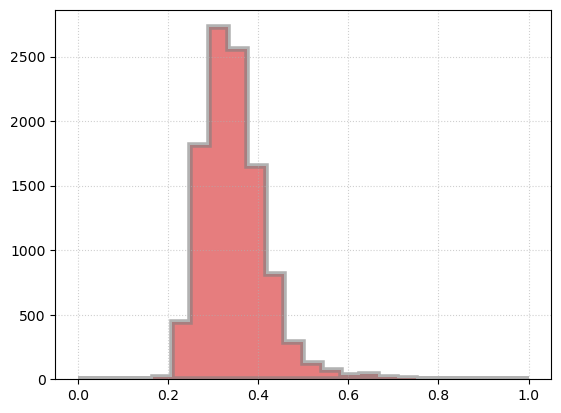

In [252]:
plt.hist(phot_tbl['qfit'], bins=np.linspace(0, 1., 25), histtype='stepfilled', lw=4, fc='C3', ec='gray', alpha=0.6)
plt.grid(ls=':', alpha=0.6)

print(np.sum(phot_tbl['qfit'] > 1.))

0


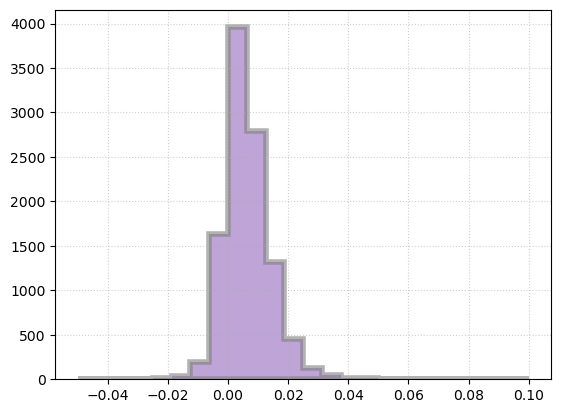

In [249]:
plt.hist(phot_tbl['cfit'], bins=np.linspace(-.05, 0.1, 25), histtype='stepfilled', lw=4, fc='C4', ec='gray', alpha=0.6)
plt.grid(ls=':', alpha=0.6)

print(np.sum(phot_tbl['cfit'] > 0.1))

0 :: Fit (x,y): (18.94, 12.40) || Init (x,y): (19.00, 12.00)
1 :: Fit (x,y): (38.03, 12.58) || Init (x,y): (38.00, 13.00)
2 :: Fit (x,y): (56.78, 12.84) || Init (x,y): (57.00, 13.00)
3 :: Fit (x,y): (75.88, 12.99) || Init (x,y): (76.00, 13.00)
4 :: Fit (x,y): (94.82, 13.27) || Init (x,y): (95.00, 13.00)
107 :: Fit (x,y): (19.40, 32.39) || Init (x,y): (19.00, 32.00)
108 :: Fit (x,y): (38.62, 32.82) || Init (x,y): (39.00, 33.00)
109 :: Fit (x,y): (57.32, 33.01) || Init (x,y): (57.00, 33.00)
110 :: Fit (x,y): (76.47, 33.21) || Init (x,y): (77.00, 33.00)
111 :: Fit (x,y): (95.33, 33.51) || Init (x,y): (95.00, 33.00)
214 :: Fit (x,y): (20.07, 53.24) || Init (x,y): (20.00, 53.00)
215 :: Fit (x,y): (39.00, 53.64) || Init (x,y): (39.00, 54.00)
216 :: Fit (x,y): (57.98, 53.76) || Init (x,y): (58.00, 54.00)
217 :: Fit (x,y): (76.98, 53.79) || Init (x,y): (77.00, 54.00)
218 :: Fit (x,y): (95.95, 54.23) || Init (x,y): (96.00, 54.00)
321 :: Fit (x,y): (20.59, 74.11) || Init (x,y): (21.00, 74.00)
32

(0.0, 105.0)

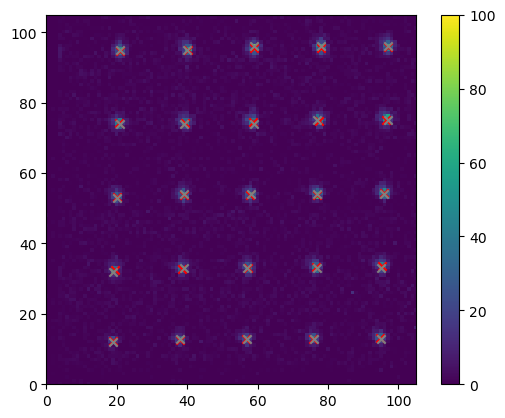

In [109]:
# Plot resulting fit 
loc = np.where( (phot_tbl['x_init'] < 100.) & (phot_tbl['y_init'] < 100.) )[0]


plt.imshow(cube[0], vmin=0, vmax=100)
plt.colorbar()

for i in loc:
    
#     display(phot_tbl[i])
    
    xfit = phot_tbl['x_fit'][i]
    yfit = phot_tbl['y_fit'][i]
    xinit = phot_tbl['x_init'][i]
    yinit = phot_tbl['y_init'][i]
    print(f'{i} :: Fit (x,y): ({xfit:0.2f}, {yfit:0.2f}) || Init (x,y): ({xinit:0.2f}, {yinit:0.2f})')
    plt.scatter(phot_tbl['x_fit'][i], phot_tbl['y_fit'][i], marker='x', color='r')
    plt.scatter(phot_tbl['x_init'][i], phot_tbl['y_init'][i], marker='x', color='gray')
    
    
    
plt.xlim(0,105)
plt.ylim(0,105)

id,group_id,group_size,local_bkg,x_init,y_init,flux_init,x_fwhm_init,y_fwhm_init,theta_init,x_fit,y_fit,flux_fit,x_fwhm_fit,y_fwhm_fit,theta_fit,x_err,y_err,flux_err,x_fwhm_err,y_fwhm_err,theta_err,npixfit,qfit,cfit,flags
int64,int64,int64,float64,float64,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64
5750,5750,1,0.0,1218.0,1110.0,319.00406,1.5,1.5,0.0,1217.5412440338632,1109.5453479942953,399.72566655594954,1.8230205444648941,0.3992364327824151,-450.17266151637256,587.6581261061589,0.6721505887423845,56.558178073070486,0.4769118949253888,4566.176209231439,2536.767158946928,81,0.8697899418803507,0.0046856365648844656,0


1.8230205444648941 0.3992364327824151
Best fit theta: 0.00


(1104.0, 1116.0)

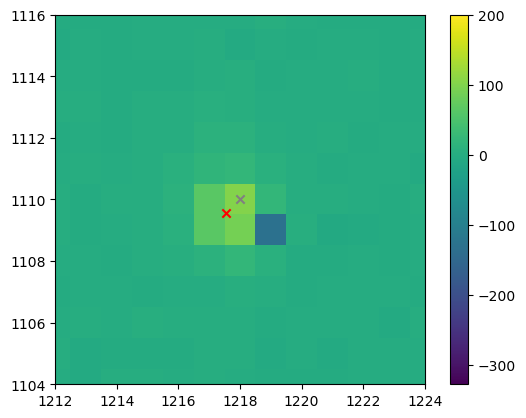

In [233]:
# Look at individual problematic fits

i = np.where(xerr_check)[0]
display(phot_tbl[i])

x_init = phot_tbl['x_init'][i].value[0]
y_init = phot_tbl['y_init'][i].value[0]

x_fit = phot_tbl['x_fit'][i].value[0]
y_fit = phot_tbl['y_fit'][i].value[0]

x_fwhm = phot_tbl['x_fwhm_fit'][i].value[0]
y_fwhm = phot_tbl['y_fwhm_fit'][i].value[0]

# Best fit standard deviation
x_sigma = x_fwhm / (2. * np.sqrt(2. * np.log(2.)))
y_sigma = y_fwhm / (2. * np.sqrt(2. * np.log(2.)))

print(x_fwhm, y_fwhm)

# Construct covariance matrix
theta = 0. #np.deg2rad(phot_tbl['theta_fit'][i].value[0])
print(f'Best fit theta: {np.rad2deg(theta):0.2f}')
S = np.diag([x_sigma**2, y_sigma**2])
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
newcov = R@S@R.T


# Make and plot contour
N    = 100
X    = np.linspace(0, 10, N)
Y    = np.linspace(0, 10, N)
X, Y = np.meshgrid(X, Y)
pos  = np.dstack((X, Y))
rv   = multivariate_normal([x_fit, y_fit], newcov, allow_singular=True)
Z    = rv.pdf(pos)


plt.imshow(cube[0], vmax=200)
plt.colorbar()
plt.contour(X, Y, Z, cmap='Reds', levels=5)

plt.scatter(x_init, y_init, marker='x', color='gray')
plt.scatter(x_fit, y_fit, marker='x', color='r')
plt.xlim(x_init-6, x_init+6)
plt.ylim(y_init-6, y_init+6)

In [237]:
np.all(Z==0)


True

Text(0.5, 1.0, 'FWHM x / FWHM y')

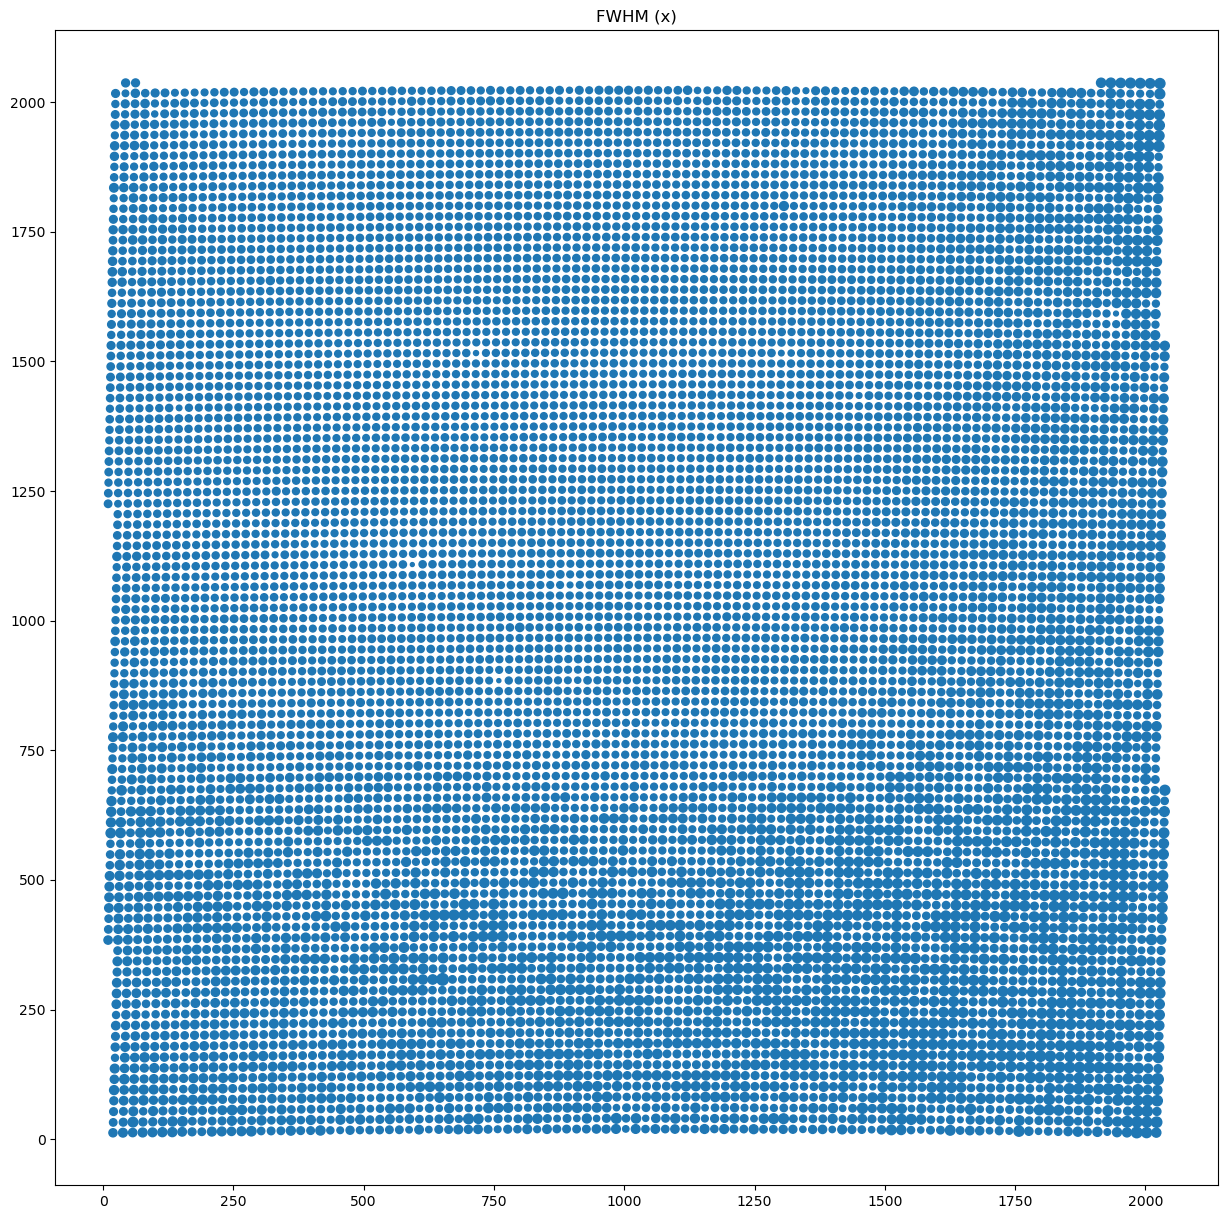

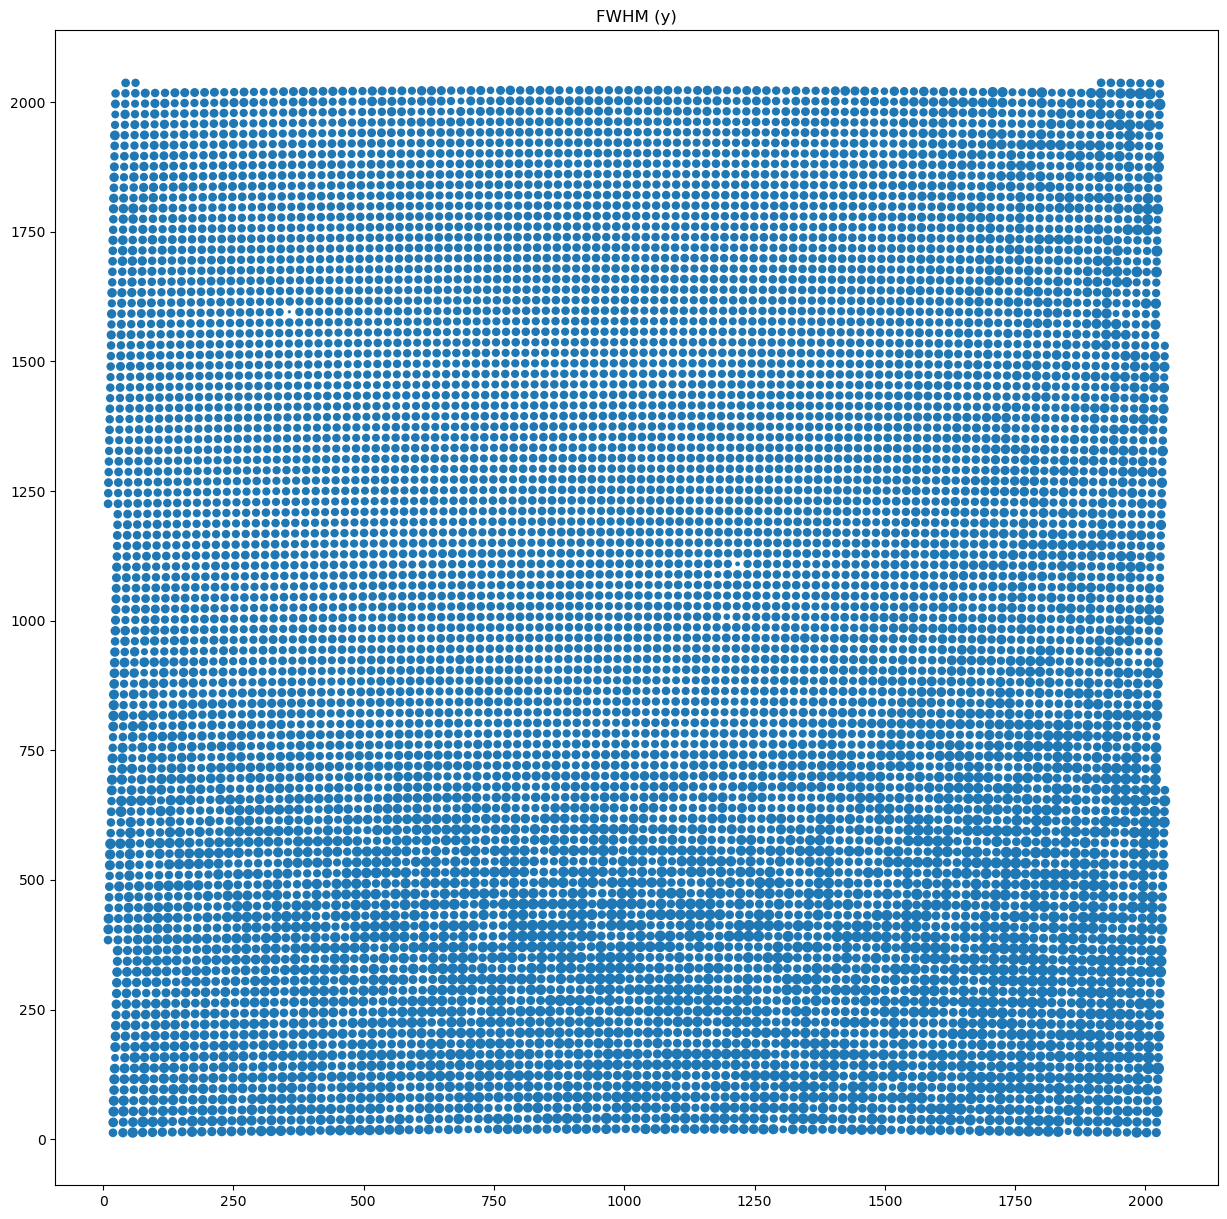

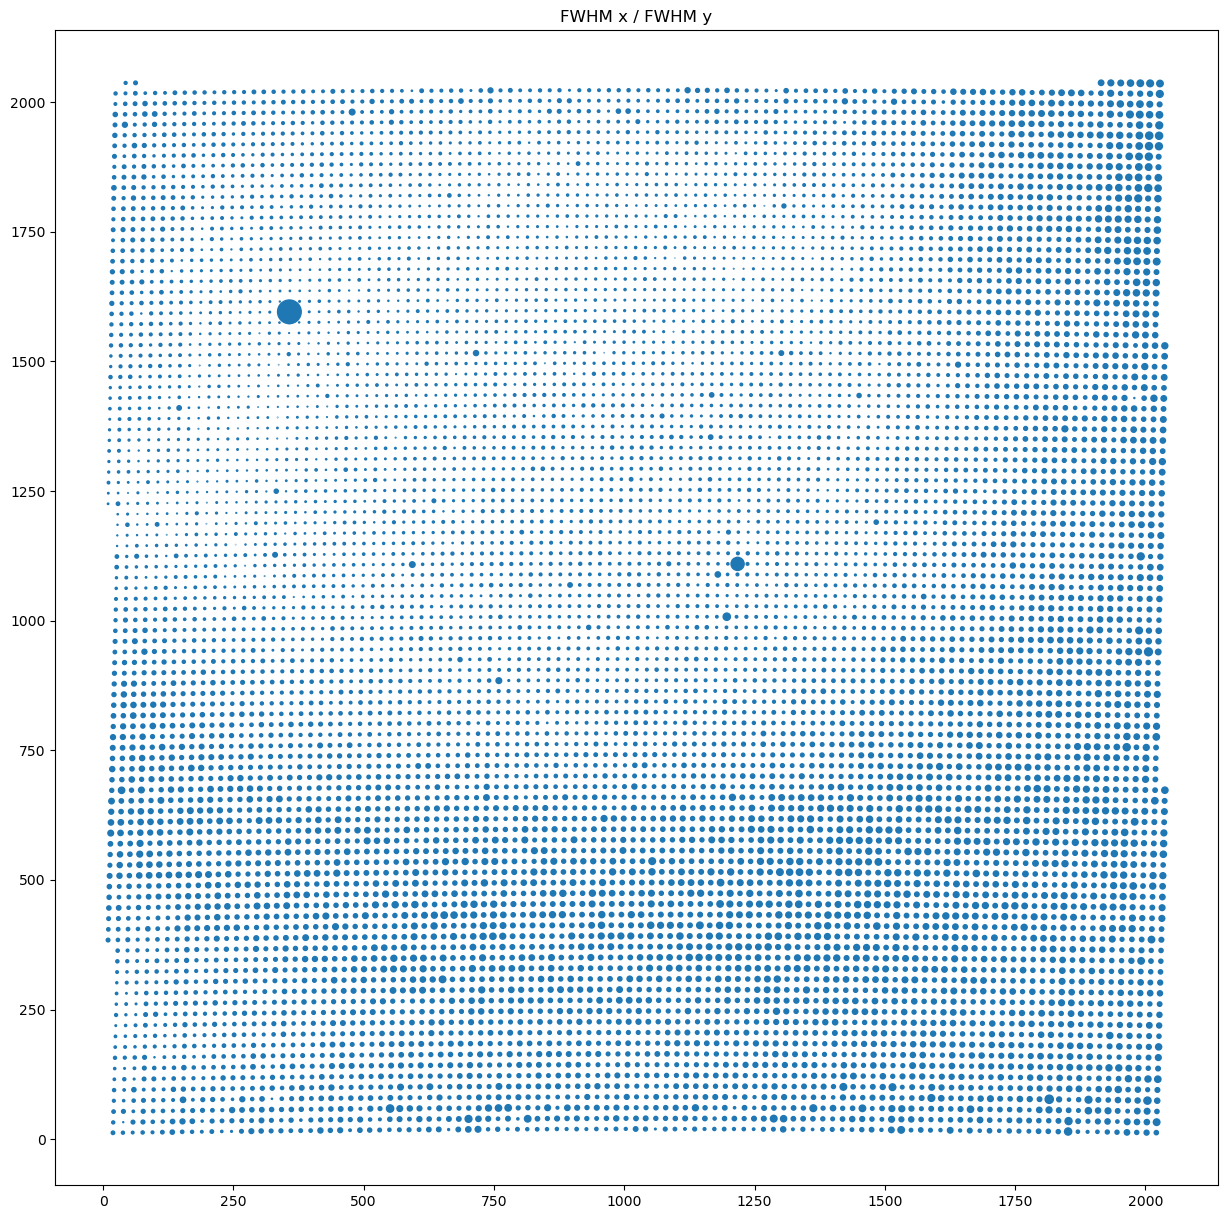

In [124]:
# Plot FWHM over the FOV

x_init = phot_tbl['x_init'].value
y_init = phot_tbl['y_init'].value

x_fit = phot_tbl['x_fit'].value
y_fit = phot_tbl['y_fit'].value

x_fwhm = phot_tbl['x_fwhm_fit'].value
y_fwhm = phot_tbl['y_fwhm_fit'].value

# Best fit standard deviation
x_sigma = x_fwhm / (2. * np.sqrt(2. * np.log(2.)))
y_sigma = y_fwhm / (2. * np.sqrt(2. * np.log(2.)))


plt.figure(figsize=(15,15))
plt.scatter(x_fit, y_fit, s=x_fwhm*15.)
plt.title('FWHM (x)')

plt.figure(figsize=(15,15))
plt.scatter(x_fit, y_fit, s=y_fwhm*15.)
plt.title('FWHM (y)')

plt.figure(figsize=(15,15))
plt.scatter(x_fit, y_fit, s=np.abs(x_fwhm/y_fwhm - 1.)*25.)
plt.title('FWHM x / FWHM y')

Text(0.5, 1.0, 'Spot ellipticity (|FWHMx/FWHMy|-1)')

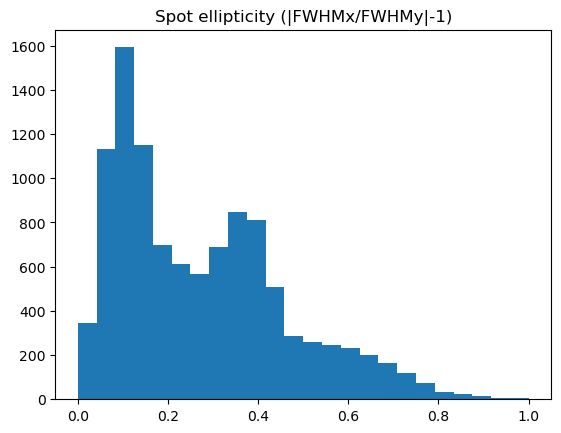

In [125]:
# Distribution of spot ellipticity

plt.hist(np.abs(x_fwhm/y_fwhm - 1.), bins=np.linspace(-0.1, 1, 25))
plt.title('Spot ellipticity (|FWHMx / FWHMy| - 1)')

Text(0.5, 1.0, 'Spot ellipticity (|FWHMy / FWHMx| - 1)')

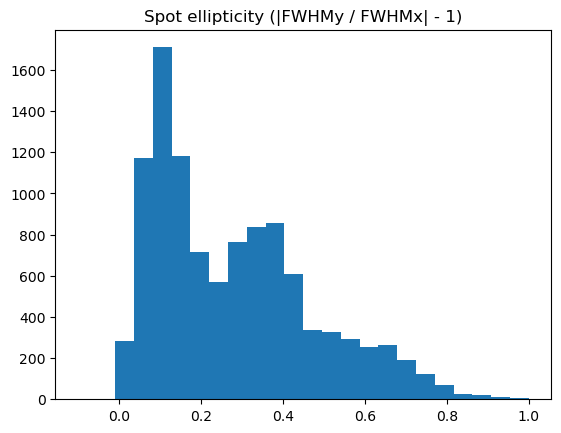

In [171]:
# Sanity check, make sure inverse distribution looks the same

plt.hist(np.abs(y_fwhm/x_fwhm - 1.), bins=np.linspace(-0.1, 1, 25))
plt.title('Spot ellipticity (|FWHMy / FWHMx| - 1)')

## Reshape results

In [153]:
## Read out results from fitting

# Initial centroid position
x_init_dropnan = phot_tbl['x_init'].value
y_init_dropnan = phot_tbl['y_init'].value

# Best-fit centroid position
x_fit_dropnan = phot_tbl['x_fit'].value
y_fit_dropnan = phot_tbl['y_fit'].value

# FWHM in x, y directions
x_fwhm_dropnan = phot_tbl['x_fwhm_fit'].value
y_fwhm_dropnan = phot_tbl['y_fwhm_fit'].value

# Orientation angle of ellipse
theta_dropnan = phot_tbl['theta_fit'].value

# Best fit standard deviation
x_sigma_dropnan = x_fwhm_dropnan / (2. * np.sqrt(2. * np.log(2.)))
y_sigma_dropnan = y_fwhm_dropnan / (2. * np.sqrt(2. * np.log(2.)))



In [154]:
## Insert NaN values that were initially dropped to return all arrays to 11330-length array

# Reconstruct temp array of zero-val placeholders and NaN values of length 11330
temp = np.zeros(len(np.ravel(xyinf))) # xyinf=True means value is finite
temp[~np.ravel(xyinf)] = np.nan


# Reconstruct len 11330 initial centroid position
x_init = np.copy(temp)
x_init[np.ravel(xyinf)] = x_init_dropnan

y_init = np.copy(temp)
y_init[np.ravel(xyinf)] = y_init_dropnan

# print(np.shape(x_init), np.sum(np.isfinite(x_init))/len(x_init))
# print(np.shape(x_init), np.sum(np.isfinite(x_init))/len(x_init))


# Reconstruct len 11330 best-fit centroid position
x_fit = np.copy(temp)
x_fit[np.ravel(xyinf)] = x_fit_dropnan

y_fit = np.copy(temp)
y_fit[np.ravel(xyinf)] = y_fit_dropnan


# Reconstruct len 11330 FWHM in x, y directions
x_fwhm = np.copy(temp)
x_fwhm[np.ravel(xyinf)] = x_fwhm_dropnan

y_fwhm = np.copy(temp)
y_fwhm[np.ravel(xyinf)] = y_fwhm_dropnan


# Reconstruct len 11330 orientation angle of ellipse
theta = np.copy(temp)
theta[np.ravel(xyinf)] = theta_dropnan


# Reconstruct len 11330 best fit standard deviation
x_sigma = np.copy(temp)
x_sigma[np.ravel(xyinf)] = x_sigma_dropnan

y_sigma = np.copy(temp)
y_sigma[np.ravel(xyinf)] = y_sigma_dropnan


In [157]:
## Reshape into (103x110) array

x_init_reshape = np.reshape(x_init, np.shape(a[0,:,:,0]), order='C')
y_init_reshape = np.reshape(y_init, np.shape(a[0,:,:,3]), order='C')

x_fit_reshape = np.reshape(x_fit, np.shape(a[0,:,:,0]), order='C')
y_fit_reshape = np.reshape(y_fit, np.shape(a[0,:,:,3]), order='C')

x_fwhm_reshape = np.reshape(x_fwhm, np.shape(a[0,:,:,0]), order='C')
y_fwhm_reshape = np.reshape(y_fwhm, np.shape(a[0,:,:,3]), order='C')

theta_reshape = np.reshape(theta, np.shape(a[0,:,:,0]), order='C')

x_sigma_reshape = np.reshape(x_sigma, np.shape(a[0,:,:,0]), order='C')
y_sigma_reshape = np.reshape(y_sigma, np.shape(a[0,:,:,3]), order='C')


In [159]:
np.shape(x_fit_reshape)

(103, 110)

In [191]:
# Check that initial centroid x,y coords are monotonically increasing

xx_sep_init = np.diff(x_init_reshape, axis=1) # diff between x coords along x axis
xy_sep_init = np.diff(x_init_reshape, axis=0) # diff between x coords along y axis (should hover around 0)
yy_sep_init = np.diff(y_init_reshape, axis=0) # diff between y coords along y axis
yx_sep_init = np.diff(y_init_reshape, axis=1) # diff between y coords along x axis (should hover around 0)


# Check that fitted centroid x,y coords are monotonically increasing

xx_sep_fit = np.diff(x_fit_reshape, axis=1) # diff between x coords along x axis
xy_sep_fit = np.diff(x_fit_reshape, axis=0) # diff between x coords along y axis (should hover around 0)
yy_sep_fit = np.diff(y_fit_reshape, axis=0) # diff between y coords along y axis
yx_sep_fit = np.diff(y_fit_reshape, axis=1) # diff between y coords along x axis (should hover around 0)

# There should be NO values leq to zero
print( np.sum( xx_sep_init <= 0 ), np.sum( yy_sep_init <= 0 ) )
print( np.sum( xx_sep_fit <= 0 ), np.sum( yy_sep_fit <= 0 ) )

# These values should hover around zero, may be some values leq zero
print( np.sum( xy_sep_init <= 0 ), np.sum( yx_sep_init <= 0 ) )
print( np.sum( xy_sep_fit <= 0 ), np.sum( yx_sep_fit <= 0 ) )


0 0
0 0
5881 9797
2 5295


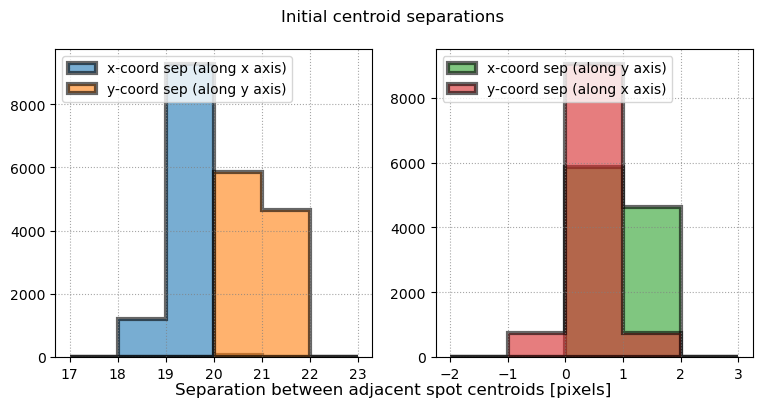

In [231]:
# Histogram separations

fig, ax = plt.subplots(1, 2, figsize=(9,4))
ax[0].hist(np.ravel(xx_sep_init), bins=np.arange(17, 24), histtype='stepfilled', lw=3, alpha=0.6, ec='k', label='x-coord sep (along x axis)')
ax[0].hist(np.ravel(yy_sep_init), bins=np.arange(17, 24), histtype='stepfilled', lw=3, alpha=0.6, ec='k', label='y-coord sep (along y axis)')
ax[0].legend(loc='upper left')

ax[1].hist(np.ravel(xy_sep_init), bins=np.arange(-2, 4), histtype='stepfilled', lw=3, alpha=0.6, ec='k', color='C2', label='x-coord sep (along y axis)')
ax[1].hist(np.ravel(yx_sep_init), bins=np.arange(-2, 4), histtype='stepfilled', lw=3, alpha=0.6, ec='k', color='C3', label='y-coord sep (along x axis)')
ax[1].legend(loc='upper left')

# fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.suptitle('Initial centroid separations');
fig.supxlabel('Separation between adjacent spot centroids [pixels]')
ax[0].grid(color='gray', alpha=0.7, ls=':')
ax[1].grid(color='gray', alpha=0.7, ls=':');


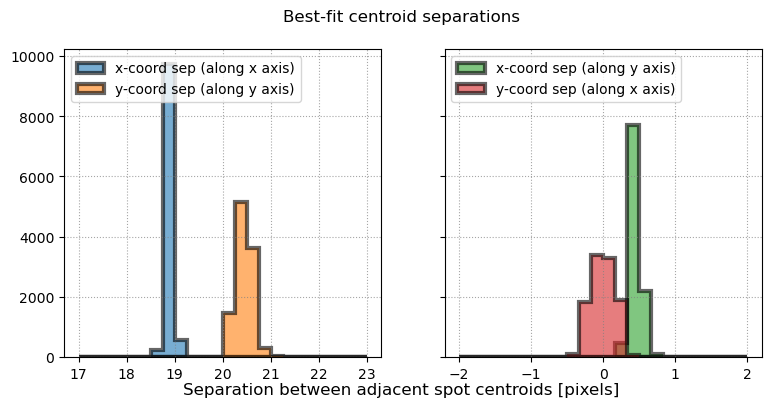

In [232]:
# Histogram separations

fig, ax = plt.subplots(1, 2, figsize=(9,4), sharey=True)
# plt.tight_layout()

ax[0].hist(np.ravel(xx_sep_fit), bins=np.linspace(17, 23, 25), histtype='stepfilled', lw=3, alpha=0.6, ec='k', label='x-coord sep (along x axis)')
ax[0].hist(np.ravel(yy_sep_fit), bins=np.linspace(17, 23, 25), histtype='stepfilled', lw=3, alpha=0.6, ec='k', label='y-coord sep (along y axis)')
ax[0].legend(loc='upper left')

ax[1].hist(np.ravel(xy_sep_fit), bins=np.linspace(-2, 2, 25), histtype='stepfilled', lw=3, alpha=0.6, ec='k', color='C2', label='x-coord sep (along y axis)')
ax[1].hist(np.ravel(yx_sep_fit), bins=np.linspace(-2, 2, 25), histtype='stepfilled', lw=3, alpha=0.6, ec='k', color='C3', label='y-coord sep (along x axis)')
ax[1].legend(loc='upper left')

# fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.suptitle('Best-fit centroid separations');
fig.supxlabel('Separation between adjacent spot centroids [pixels]')
ax[0].grid(color='gray', alpha=0.7, ls=':')
ax[1].grid(color='gray', alpha=0.7, ls=':');


## Scriptify

In [272]:
np.shape(a)

(56, 103, 110, 6)

In [47]:
# Read in coarse centroid matrix
cube = fits.getdata('20251027_mono_cube_L_new.fits')
a = fits.getdata('L_positions_new.fits')


def fit_spots(params):
    '''
    data :: (2048, 2048) slice from SCALES monochrometer cube (background-subtracted & reduced)
    pos  :: (103, 110, 6)
    current cube shape: (56, 2048, 2048)
    current a shape: (56, 103, 110, 6)
    
    This fits a 2D gaussian to each spot in a slice of monochrometer SCALES IFU data. It returns a (6,103,110)
    array: [x_centroid_fit, y_centroid_fit, x_fwhm, y_fwhm, theta, quality_flags]
    '''
    
    # Extract cube slice, centroid positions from params
    data = params[0] # 2048x2048 slice of IFU datacube
    pos = params[1]  # 103x110x6 array with info about coarse spot centroids

    # Drop NaN centroids (spots that fell off the detector)
    xinf = np.isfinite(pos[:,:,0])
    yinf = np.isfinite(pos[:,:,3])
    xyinf = np.logical_and( xinf, yinf )

    # Extract (x,y) coarse centroid positions as 1D array
    xpos = np.ravel(pos[xyinf, 0])
    ypos = np.ravel(pos[xyinf, 3])

    #########################
    ## DO 2D GAUSS FITTING ##
    #########################

    # Fit circular 2D Gaussians to each centroided spot with photutils
    psfphot = fit_2dgaussian_assym(data, xypos=list(zip(xpos, ypos)), fwhm=1.5, fit_shape=9, fix_fwhm=False) # takes 68s to fit all 110x103 spots

    # Extract fitting results
    phot_tbl = psfphot.results


    #########################
    ## CHECK RESULTS       ##
    #########################

    # Check if any best-fit parameters are unreasonable
    flag_check = phot_tbl['flags'] > 0           # if any flags raised
    fwhmx_check = phot_tbl['x_fwhm_fit'] > 5.    # if FWHM_x larger than certain threshold
    fwhmy_check = phot_tbl['y_fwhm_fit'] > 5.    # if FWHM_y larger than certain threshold
    xerr_check = phot_tbl['x_err'] > 0.5         # uncertainty in centroid X position
    yerr_check = phot_tbl['y_err'] > 0.5         # uncertainty in centroid Y position
    qfit_check = np.abs(phot_tbl['qfit']) > 1.0  # quality-of-fit from residuals (zero is perfect)
    cfit_check = np.abs(phot_tbl['cfit']) > 0.1  # broadness/peakiness of PSF fit (zero is perfect)

    print('****** FIT FLAGS ******')
    print('photutils fit flags:', np.sum(flag_check))
    print('FWHM_x > 5px:       ', np.sum(fwhmx_check))
    print('FWHM_y > 5px:       ', np.sum(fwhmy_check))
    print('x_err > 0.5px:      ', np.sum(xerr_check))
    print('y_err > 0.5px:      ', np.sum(yerr_check))
    print('qfit > 1.0:         ', np.sum(qfit_check))
    print('cfit > 0.1:         ', np.sum(cfit_check))
    print('***********************')

    # Raise flag if any params are out of range (ignore qfit_check, cfit_check for now, unsure how to treat)
    quality_flag = np.any([flag_check, fwhmx_check, fwhmy_check, xerr_check, yerr_check], axis=0)


    ############################
    ## READ & RESHAPE RESULTS ##
    ############################

    ## Read out parameters from photutils output table

    # Best-fit centroid position
    x_fit_dropnan = phot_tbl['x_fit'].value
    y_fit_dropnan = phot_tbl['y_fit'].value

    # FWHM in x, y directions
    x_fwhm_dropnan = phot_tbl['x_fwhm_fit'].value
    y_fwhm_dropnan = phot_tbl['y_fwhm_fit'].value

    # Orientation angle of ellipse
    theta_dropnan = phot_tbl['theta_fit'].value


    ## Insert NaN values that were initially dropped to return all arrays to 11330-length array

    # Create temp array
    temp = np.zeros(len(np.ravel(xyinf))) # xyinf=True means value is finite
    temp[~np.ravel(xyinf)] = np.nan

    # Reconstruct len 11330 best-fit centroid positions
    x_fit_ravel = np.copy(temp)
    x_fit_ravel[np.ravel(xyinf)] = x_fit_dropnan

    y_fit_ravel = np.copy(temp)
    y_fit_ravel[np.ravel(xyinf)] = y_fit_dropnan

    # Reconstruct len 11330 FWHM in x, y directions
    x_fwhm_ravel = np.copy(temp)
    x_fwhm_ravel[np.ravel(xyinf)] = x_fwhm_dropnan

    y_fwhm_ravel = np.copy(temp)
    y_fwhm_ravel[np.ravel(xyinf)] = y_fwhm_dropnan

    # Reconstruct len 11330 orientation angle of ellipse
    theta_ravel = np.copy(temp)
    theta_ravel[np.ravel(xyinf)] = theta_dropnan

    # Reconstruct len 11330 quality flags array
    quality_ravel = np.copy(temp)
    quality_ravel[np.ravel(xyinf)] = quality_flag
    
    
    ## Reshape 6 fitting parameters and return results

    x_fit = np.reshape(x_fit_ravel, np.shape(pos[:,:,0]), order='C')
    y_fit = np.reshape(y_fit_ravel, np.shape(pos[:,:,3]), order='C')
    x_fwhm = np.reshape(x_fwhm_ravel, np.shape(pos[:,:,0]), order='C')
    y_fwhm = np.reshape(y_fwhm_ravel, np.shape(pos[:,:,3]), order='C')
    theta = np.reshape(theta_ravel, np.shape(pos[:,:,0]), order='C')
    quality = np.reshape(quality_ravel, np.shape(pos[:,:,0]), order='C')

    results = np.array([x_fit, y_fit, x_fwhm, y_fwhm, theta, quality])
    
    return results


FileNotFoundError: [Errno 2] No such file or directory: '20251027_mono_cube_L_new.fits'

In [197]:
# Read in coarse centroid matrix
cube = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool/data/20251027_mono_cube_L_new.fits')
a = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool/data/L_positions_new.fits')


np.shape(a[:,:,0])

(56, 103, 6)

## Do multithreading

In [12]:
import concurrent.futures

# Read in datacube, spot centroids
cube = fits.getdata('20251027_mono_cube_L_new.fits')
a = fits.getdata('L_positions_new.fits')

# Set up inputs as list of tuples
# param_list = [(cube[i], a[i, :, :, :]) for i in range(0, np.shape(cube)[0])]
param_list = [(cube[i], a[i, :, :, :]) for i in range(0, 5)]
print(len(param_list))


# Do multithreading

with concurrent.futures.ProcessPoolExecutor() as executor:
    futures = [executor.submit(fit_spots, param) for param in param_list]
    returns = [f.result() for f in futures] 
    print(np.shape(returns))
    
    
    

# For those wondering this can be done with a list of threads. 
# futures = [executor.submit(foo, param) for param in param_list] 
# The order will be maintained, and exiting the with will allow result collection. 
# [f.result() for f in futures] 




5


Process SpawnProcess-6:
Traceback (most recent call last):
  File "/Users/isabelkain/anaconda3/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/isabelkain/anaconda3/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/isabelkain/anaconda3/lib/python3.11/concurrent/futures/process.py", line 244, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/isabelkain/anaconda3/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'fit_spots' on <module '__main__' (built-in)>


KeyboardInterrupt: 

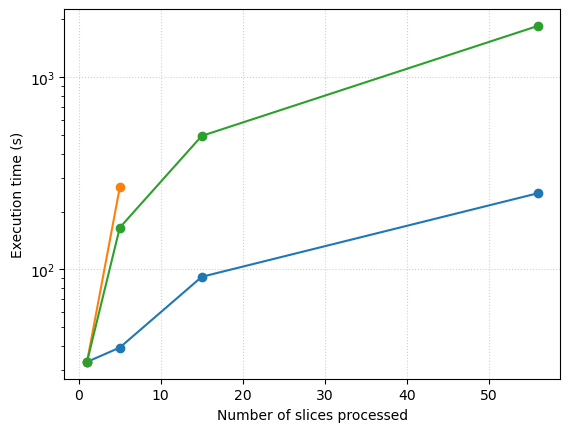

In [29]:
# Sanity check execution times for different task handling methods

slicenum_mp = np.array([1, 5, 15, 56])
extime_mp = np.array([33., 39.2, 91.5, 249.0])

slicenum_mt = np.array([1, 5])
extime_mt = np.array([33., 267.1])

slicenum_lin = np.array([1, 5, 15, 56])
extime_lin = slicenum_lin*33.

plt.plot(slicenum_mp, extime_mp, marker='o')
plt.plot(slicenum_mt, extime_mt, marker='o')
plt.plot(slicenum_lin, extime_lin, marker='o')
plt.yscale('log')
plt.ylabel('Execution time (s)')
plt.xlabel('Number of slices processed')
plt.grid(ls=':', alpha=0.6)

## Measure direction of dispersion

In [50]:
results = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool/results/L_psf_fitting_results.fits')
np.shape(results)

(56, 6, 103, 110)

In [ ]:
# Theta hist



(55, 103, 110) (55, 103, 110)


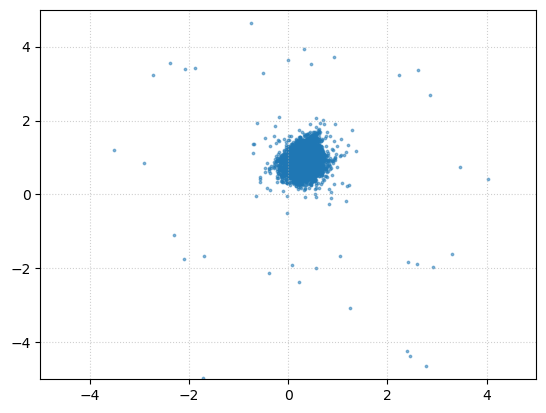

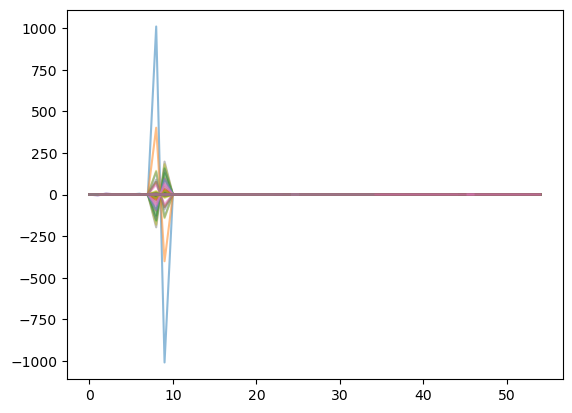

In [6]:
# Look at centroid pixel shift between subsequent wavelength slices

# [wav, 0, :, :] = x_cen
# [wav, 1, :, :] = y_cen

x_cen_shift = np.diff(results[:, 0, :, :], axis=0)
y_cen_shift = np.diff(results[:, 1, :, :], axis=0)
print(np.shape(x_cen_shift), np.shape(y_cen_shift))

plt.figure()
plt.scatter(np.ravel(x_cen_shift), np.ravel(y_cen_shift), alpha=0.5, s=3)
plt.grid(ls=':', alpha=0.6)
plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.figure()
# for ix in np.ndindex(np.shape(results)[2:]):
#     print(ix)
#     print(np.shape(x_cen_shift[:, ix]))
#     plt.plot( results[ix], alpha=0.5 )

for i in range(0, np.shape(results)[2]):
    for j in range(0, np.shape(results)[3]):
        plt.plot( x_cen_shift[:, i, j], alpha=0.5 )

/Users/isabelkain/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/2207831615.py:6: RuntimeWarning: Mean of empty slice
  disp_mean = np.nanmean(disp_dir, axis=0)
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/2207831615.py:7: RuntimeWarning: All-NaN slice encountered
  disp_medn = np.nanmedian(disp_dir, axis=0)


Text(0.5, 0, 'Angular centroid shift between wavelength slices (deg from vertical)')

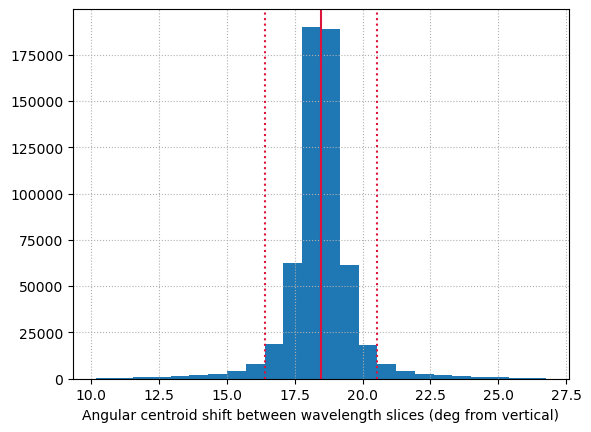

In [9]:
# Measure angular centroid shift between wavelength slices
disp_dir = np.rad2deg( np.arctan(x_cen_shift/y_cen_shift) ) # angle from vertical axis (55x103x110)

# Measure statistics for each micropupil (along wavelength axis)
disp_stdv = np.nanstd(disp_dir, axis=0) # 103x110 array
disp_mean = np.nanmean(disp_dir, axis=0)
disp_medn = np.nanmedian(disp_dir, axis=0)
# print(np.shape(disp_stdv), np.shape(disp_mean))

# Measure statistics across all spots and all slices
disp_stdv_all = np.nanstd(np.ravel(disp_dir)) # scalar
disp_mean_all = np.nanmean(np.ravel(disp_dir))
# print(np.shape(disp_stdv_all), np.shape(disp_mean_all))

# Count how many slices show shifts >1 sigma for each spot (103x110 array)
outlier = np.logical_or( (disp_dir > (disp_mean + disp_stdv)), (disp_dir < (disp_mean - disp_stdv)) ) # (55x103x110 array)
num_outlier = np.sum(outlier, axis=0) # (103x110)


# print(np.nanmin(disp_dir), np.nanmax(disp_dir), np.nanmedian(disp_dir), disp_mean, disp_stdv)


# Plot histogram of all centroid shifts (all spots, all wavelength slices)
plt.hist(np.ravel(disp_dir), bins=np.linspace(disp_mean_all-4*disp_stdv_all, disp_mean_all+4*disp_stdv_all, 25 ));
plt.grid(ls=':')
plt.axvline(disp_mean_all, color='crimson')
plt.axvline(disp_mean_all-disp_stdv_all, color='crimson', ls=':')
plt.axvline(disp_mean_all+disp_stdv_all, color='crimson', ls=':')
plt.xlabel('Angular centroid shift between wavelength slices (deg from vertical)')


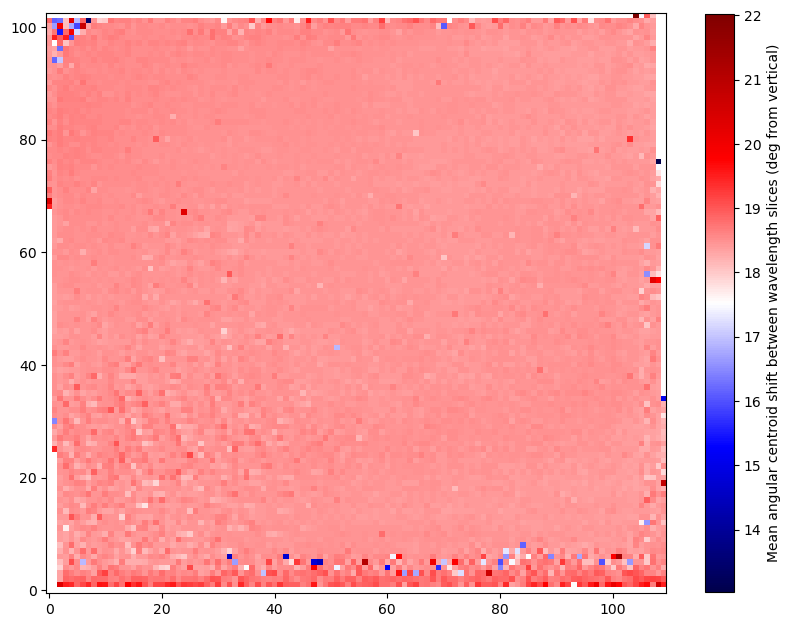

In [11]:
# Look at angular centroid shift between wavelength slices across grid

plt.figure(figsize=(10,10))
# plt.imshow(disp_mean[20:-20, 20:-20], cmap='seismic')
plt.imshow(disp_mean, cmap='seismic', origin='lower')
plt.colorbar(shrink=0.75, label='Mean angular centroid shift between wavelength slices (deg from vertical)')


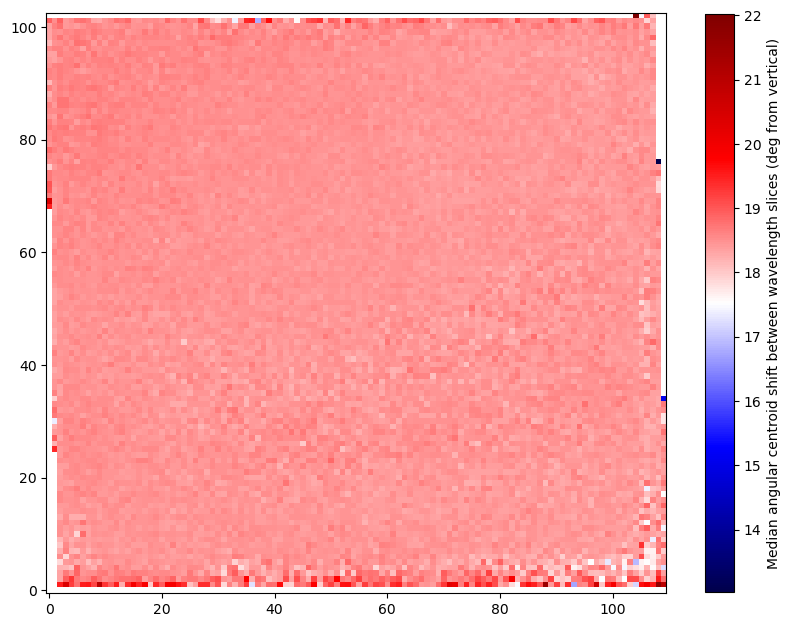

In [12]:
# Look at angular centroid shift between wavelength slices across grid

plt.figure(figsize=(10,10))
# plt.imshow(disp_mean[20:-20, 20:-20], cmap='seismic')
plt.imshow(disp_medn, cmap='seismic', origin='lower')
plt.colorbar(shrink=0.75, label='Median angular centroid shift between wavelength slices (deg from vertical)')

Avg proportion: 0.17666372462488966


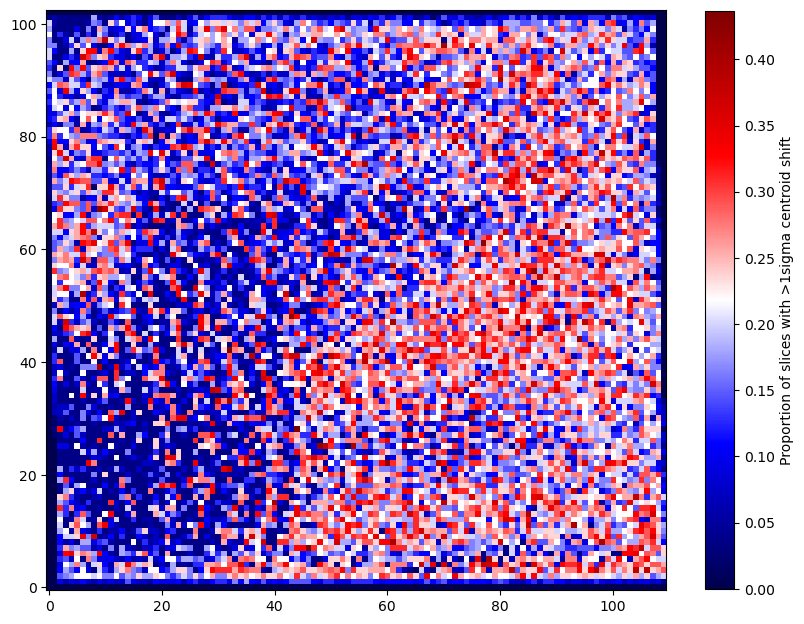

In [51]:
# For each spot, what proportion of slices had centroid shifts >1sigma from the same-spot mean

plt.figure(figsize=(10,10))
plt.imshow(num_outlier/55, cmap='seismic', origin='lower')
plt.colorbar(shrink=0.75, label='Proportion of slices with >1sigma centroid shift')


print('Avg proportion:', np.nanmean(num_outlier/55))

In [15]:
# Test different ways of calculating the dispersion direction

# print( np.nanmedian(np.nanmedian(disp_dir, axis=0)) )
# print( np.nanmedian(disp_dir) )

print( np.nanmedian(np.nanmedian(disp_dir[20:-20], axis=0)) )
print( np.nanmedian(disp_dir[20:-20]) )

print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

# print( np.nanmean(np.nanmedian(disp_dir, axis=0)) )
# print( np.nanmean(disp_dir) )

print( np.nanmean(np.nanmean(disp_dir[20:-20], axis=0)) )
print( np.nanmean(disp_dir[20:-20]) )

print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

# print( np.nanmean(np.nanmedian(disp_dir, axis=0)) )
print( np.nanmean(np.nanmedian(disp_dir[20:-20], axis=0)) )

18.472616258108907
18.47208059297298
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
18.483579390918973
18.483126852903137
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
18.471746216340247


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/1661734571.py:6: RuntimeWarning: All-NaN slice encountered
  print( np.nanmedian(np.nanmedian(disp_dir[20:-20], axis=0)) )
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/1661734571.py:14: RuntimeWarning: Mean of empty slice
  print( np.nanmean(np.nanmean(disp_dir[20:-20], axis=0)) )
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/1661734571.py:20: RuntimeWarning: All-NaN slice encountered
  print( np.nanmean(np.nanmedian(disp_dir[20:-20], axis=0)) )


In [45]:
np.sin(np.deg2rad(270))

-1.0

In [186]:
def measure_dispersion_direction(results):
    '''
    results :: (56x6x103x110) output from do_psf_fitting.py
    Returns 103x110 map of dispersion angle, medianed across wavelength
    '''
    
    # Measure shift of each individual spot centroid between adjacent wavelength slices
    x_cen_shift = np.diff(results[:, 0, :, :], axis=0)
    y_cen_shift = np.diff(results[:, 1, :, :], axis=0)
    
    # Measure angular centroid shift between wavelength slices (ndarray 55x103x110)
    disp_dir = np.rad2deg( np.arctan(y_cen_shift/x_cen_shift) ) # angle from horizontal axis 

    # Measure scalar dispersion direction
    dispersion_direction = np.nanmedian(disp_dir, axis=0)
    
    return dispersion_direction


def eccentricity(a,b):
    '''a and b are semi-major and semi-minor axes of ellipse. Can be scalar or same-shape ndarrays.'''
    return np.sqrt(1. - (b**2. / a**2.))


def wrap_angles(theta):
    '''Theta (degrees)'''
    
    theta %= 360.
    
    return theta


def diff_angles(theta, phi):
    '''
    Find difference between two angles (degrees). Assuming counterclockwise angle from the horizontal axis.
    Inputs can be either scalar or nd arrays
    '''
    
    diff = np.abs( wrap_angles(theta) - wrap_angles(phi) )
    
    return diff


def calc_ellipse_radius(a, b, phi):
    '''a and b are semimajor and semiminor axes. Offset angle of measured radius, phi, 
    is assumed to be in DEGREES'''
    
    phi_r = np.deg2rad(phi)
    
    return a * b / np.sqrt( (b * np.cos(phi_r))**2 + (a * np.sin(phi_r))**2 )


In [201]:
# Calculate dispersion direction
dispersion_direction = measure_dispersion_direction(results)
dispersion_angle = np.nanmean(dispersion_direction[60:80, 60:80])

print(np.shape(dispersion_direction))

print(f'Dispersion angle: {dispersion_angle:0.3f} deg from horizontal')


(103, 110)
Dispersion angle: 71.576 deg from horizontal


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/1242092888.py:15: RuntimeWarning: All-NaN slice encountered
  dispersion_direction = np.nanmedian(disp_dir, axis=0)


Dispersion angle: 71.576 deg from horizontal


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/1242092888.py:15: RuntimeWarning: All-NaN slice encountered
  dispersion_direction = np.nanmedian(disp_dir, axis=0)


"\nPeaks along dispersion direction and orthogonal to dispersion direction. \nMakes sense that there would be an overdensity at theta=0 – the photutils routine\nprobably defaults to this value when it can't figure out an orientation.\n"

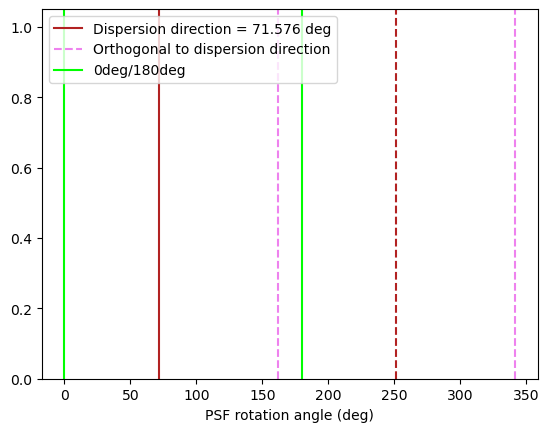

In [193]:
# Calculate dispersion direction
dispersion_direction = measure_dispersion_direction(results)
dispersion_angle = np.nanmean(dispersion_direction[60:80, 60:80])

print(f'Dispersion angle: {dispersion_angle:0.3f} deg from horizontal')


# Plot theta distribution
    
plt.hist(np.ravel(wrap_angles(theta)), bins=50)

plt.axvline(dispersion_angle, color='firebrick', label=f'Dispersion direction = {dispersion_angle:0.3f} deg')
plt.axvline(dispersion_angle+90, color='violet', ls='--', label='Orthogonal to dispersion direction')
plt.axvline(dispersion_angle+180, color='firebrick', ls='--')
plt.axvline(dispersion_angle+270, color='violet', ls='--')
# plt.axvline((dispersion_direction-90)%360., color='firebrick', ls='--')
# plt.axvline((dispersion_direction-180)%360., color='firebrick', ls='--')
# plt.axvline((dispersion_direction-270)%360., color='firebrick', ls='--')

plt.axvline(0, color='lime', label='0deg/180deg')
# plt.axvline(90, color='lime')
plt.axvline(180, color='lime')
# plt.axvline(270, color='lime')

plt.xlabel('PSF rotation angle (deg)')
plt.legend()

'''
Peaks along dispersion direction and orthogonal to dispersion direction. 
Makes sense that there would be an overdensity at theta=0 – the photutils routine
probably defaults to this value when it can't figure out an orientation.
'''



In [198]:
np.shape(results)

(56, 6, 103, 110)

## Measure FWHM in dispersion direction

In [165]:
# Simple test

a = 5.      # semimajor axis (along x direction)
b = 2.      # semiminor axis (along y direction)
theta = -110.  # rotation angle of ellipse
phi = 71.5  # dispersion angle

diff = diff_angles(theta, phi)
print(theta, phi, diff)

newrad = calc_ellipse_radius(a, b, diff)
print(newrad)

-110.0 71.5 178.5
4.9910305151827785


In [199]:
## TEST OUT FWHM_DISP

# Read in PSF-fitting parameters
cen_x = results[:, 0, :, :]
cen_y = results[:, 1, :, :]
fwhm_x = results[:, 2, :, :]
fwhm_y = results[:, 3, :, :] # for theta close to zero, fwhm_dispers should be close to fwhm_y
theta = wrap_angles(results[:, 4, :, :]) # wrap angles s.t. -360 <= theta <= 360
print(np.shape(fwhm_y), np.shape(theta)) 

print('*** THETA STATS ***')
print(f'Max: {np.nanmax(theta)} || Min: {np.nanmin(theta)} || Mean: {np.nanmean(theta)} || Median: {np.nanmedian(theta)}')
print(f'Stdev: {np.nanstd(theta)}')

# Calculate dispersion direction
dispersion_direction = measure_dispersion_direction(results)
print(f'Dispersion direction: {dispersion_direction:0.3f} deg from horizontal')

# Find angle difference between dispersion direction and rotation of PSF
diff = diff_angles(theta, dispersion_direction)
print(np.shape(diff))

# Calculate FWHM along direction of dispersion
fwhm_dispers = calc_ellipse_radius(fwhm_x, fwhm_y, diff)
print(np.shape(fwhm_dispers))


(56, 103, 110) (56, 103, 110)
*** THETA STATS ***
Max: 359.99985071986055 || Min: 0.0004154256333792983 || Mean: 187.88324697172726 || Median: 183.3277989354656
Stdev: 107.46827892515599


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/1242092888.py:15: RuntimeWarning: All-NaN slice encountered
  dispersion_direction = np.nanmedian(disp_dir, axis=0)


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [218]:
# np.shape(fwhm_dispers)

test = np.insert(results, 5, fwhm_dispers, axis=1)
print(np.shape(results), np.shape(test))

(56, 6, 103, 110) (56, 7, 103, 110)


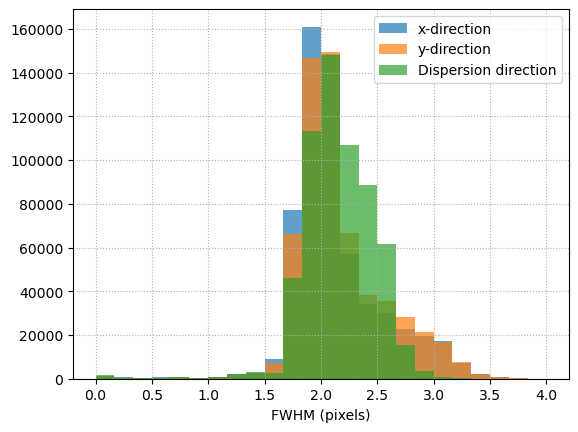

In [174]:
plt.hist(np.ravel(fwhm_x), bins=np.linspace(0, 4, 25), alpha=0.7, label='x-direction')
plt.hist(np.ravel(fwhm_y), bins=np.linspace(0, 4, 25), alpha=0.7, label='y-direction')
plt.hist(np.ravel(fwhm_dispers), bins=np.linspace(0, 4, 25), alpha=0.7, label='Dispersion direction')

plt.grid(ls=':')
plt.xlabel('FWHM (pixels)')
plt.legend()


'''
Taken across ALL micropupils
'''

/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/608494570.py:1: RuntimeWarning: All-NaN slice encountered
  plt.hist(np.ravel(np.nanmedian(fwhm_x, axis=0)), bins=np.linspace(0, 4, 25), alpha=0.7, label='x-direction')
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/608494570.py:2: RuntimeWarning: All-NaN slice encountered
  plt.hist(np.ravel(np.nanmedian(fwhm_y, axis=0)), bins=np.linspace(0, 4, 25), alpha=0.7, label='y-direction')
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/608494570.py:3: RuntimeWarning: All-NaN slice encountered
  plt.hist(np.ravel(np.nanmedian(fwhm_dispers, axis=0)), bins=np.linspace(0, 4, 25), alpha=0.7, label='Dispersion direction')


'\nTaken across ALL micropupils\n'

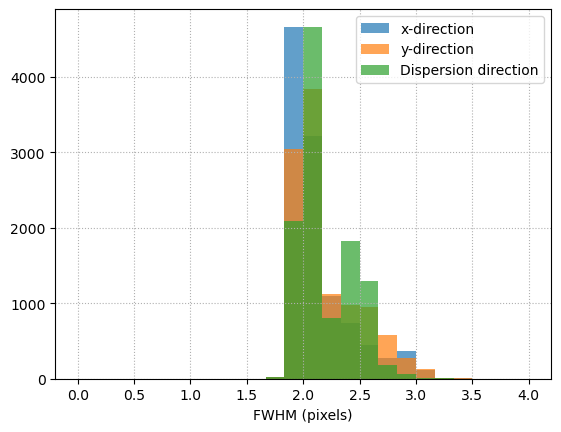

In [175]:
plt.hist(np.ravel(np.nanmedian(fwhm_x, axis=0)), bins=np.linspace(0, 4, 25), alpha=0.7, label='x-direction')
plt.hist(np.ravel(np.nanmedian(fwhm_y, axis=0)), bins=np.linspace(0, 4, 25), alpha=0.7, label='y-direction')
plt.hist(np.ravel(np.nanmedian(fwhm_dispers, axis=0)), bins=np.linspace(0, 4, 25), alpha=0.7, label='Dispersion direction')

plt.grid(ls=':')
plt.xlabel('FWHM (pixels)')
plt.legend()


'''
Medianed along wavelength axis, then histogramed across 103x110 grid
'''

/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/2181748041.py:2: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(fwhm_dispers, axis=0), origin='lower')


Text(0.5, 1.0, 'FWHM along dispersion axis')

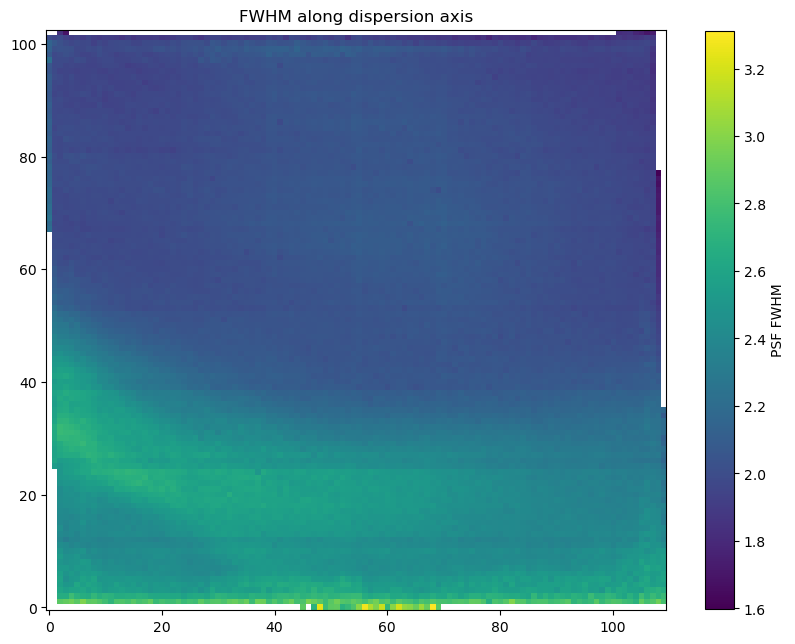

In [185]:
plt.figure(figsize=(10,10))
plt.imshow(np.nanmedian(fwhm_dispers, axis=0), origin='lower')
plt.colorbar(shrink=0.75, label='PSF FWHM')
plt.title('FWHM along dispersion axis')

/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/3149704390.py:2: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(fwhm_x, axis=0), origin='lower')


Text(0.5, 1.0, 'FWHM along major axis')

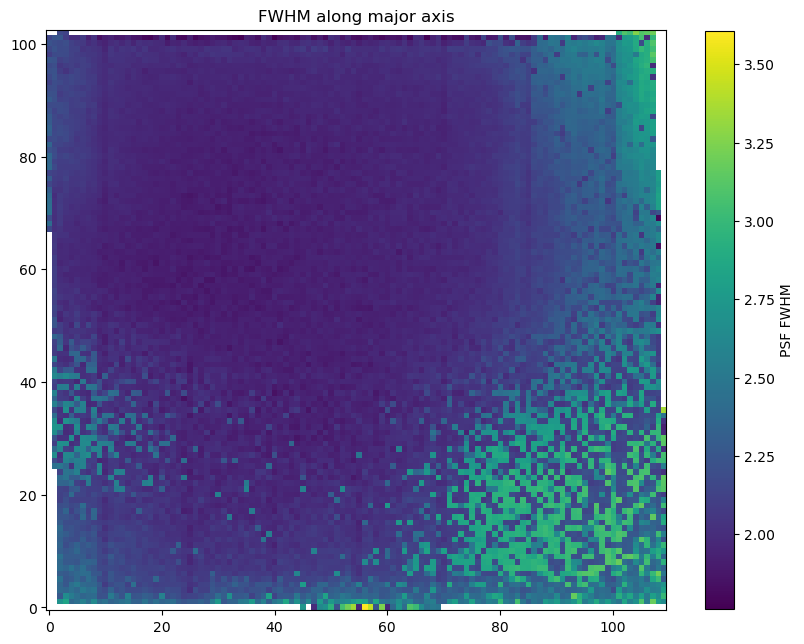

In [182]:
plt.figure(figsize=(10,10))
plt.imshow(np.nanmedian(fwhm_x, axis=0), origin='lower')
plt.colorbar(shrink=0.75, label='PSF FWHM')
plt.title('FWHM along major axis')

/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/3610773581.py:2: RuntimeWarning: All-NaN slice encountered
  plt.imshow(np.nanmedian(fwhm_y, axis=0), origin='lower')


Text(0.5, 1.0, 'FWHM along minor axis')

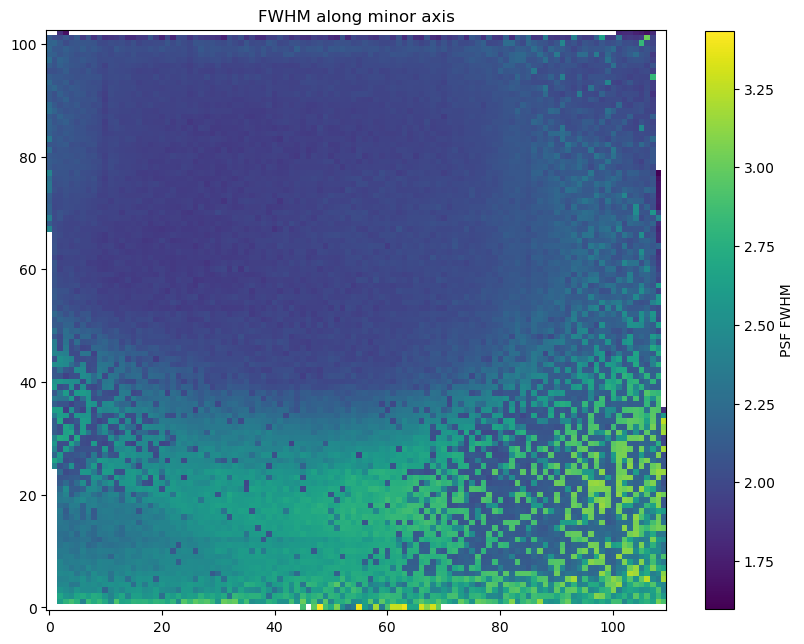

In [184]:
plt.figure(figsize=(10,10))
plt.imshow(np.nanmedian(fwhm_y, axis=0), origin='lower')
plt.colorbar(shrink=0.75, label='PSF FWHM')
plt.title('FWHM along minor axis')

/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/651876325.py:2: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(fwhm_dispers, axis=0), origin='lower')


Text(0.5, 1.0, 'FWHM along dispersion direction')

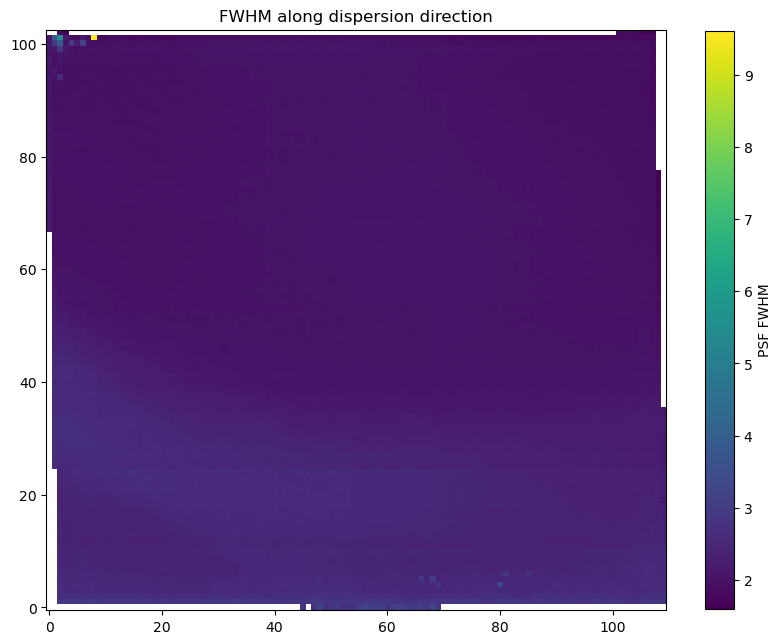

In [181]:
plt.figure(figsize=(10,10))
plt.imshow(np.nanmean(fwhm_dispers, axis=0), origin='lower')
plt.colorbar(shrink=0.75, label='PSF FWHM')
plt.title('FWHM along dispersion direction')

Text(0.5, 1.0, 'Example PSF w/ theta > 2000')

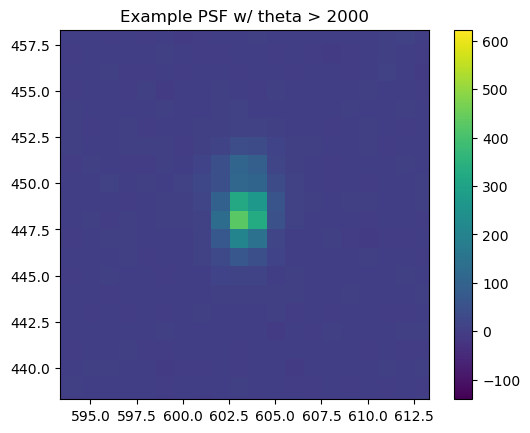

In [129]:
## Look at individual problematic PSFs (weird theta)

# cube = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool/data/20251027_mono_cube_L_new.fits')
# a = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool/data/L_positions_new.fits')

theta_thresh = 2000
pick = 2
look_x = cen_x[20, theta[20,:,:] > theta_thresh][pick]
look_y = cen_y[20, theta[20,:,:] > theta_thresh][pick]

plt.imshow(cube[20], origin='lower')
plt.xlim(look_x-10, look_x+10)
plt.ylim(look_y-10, look_y+10)
plt.colorbar()
plt.title(f'Example PSF w/ theta > {theta_thresh}')

"\nI'm not sure I believe that the FWHM along the dispersion direction is heavily skewed towards\nbeing much larger than the FWHMs taken along the semimajor axes…something is FISHY\n"

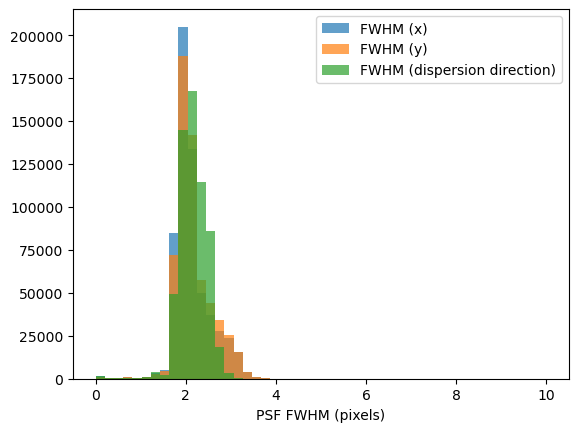

In [162]:
# Plot FWHM distributions

plt.hist(np.ravel(fwhm_x), bins=np.linspace(0, 10, 50), alpha=0.7, label='FWHM (x)');
plt.hist(np.ravel(fwhm_y), bins=np.linspace(0, 10, 50), alpha=0.7, label='FWHM (y)');
plt.hist(np.ravel(fwhm_dispers), bins=np.linspace(0, 10, 50), alpha=0.7, label='FWHM (dispersion direction)');
plt.legend()
plt.xlabel('PSF FWHM (pixels)')

'''
I'm not sure I believe that the FWHM along the dispersion direction is heavily skewed towards
being much larger than the FWHMs taken along the semimajor axes…something is FISHY
'''

Fit source/group:   0%|          | 0/1 [00:00<?, ?it/s]

id,group_id,group_size,local_bkg,x_init,y_init,flux_init,x_fwhm_init,y_fwhm_init,theta_init,x_fit,y_fit,flux_fit,x_fwhm_fit,y_fwhm_fit,theta_fit,x_err,y_err,flux_err,x_fwhm_err,y_fwhm_err,theta_err,npixfit,qfit,cfit,flags
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64
1,1,1,0.0,5.0,5.0,71.19784750080605,1.5,1.5,0.0,6.2,4.8,71.39999999999966,1.6000000000000687,3.5999999999998202,-45.09999999999998,8.428128639271204e-15,8.408295289394494e-15,4.942167912412494e-13,1.323011297854957e-14,2.5808405795181394e-14,3.4493709636303345e-13,81,5.424871069361659e-14,-3.1160881531496136e-15,0


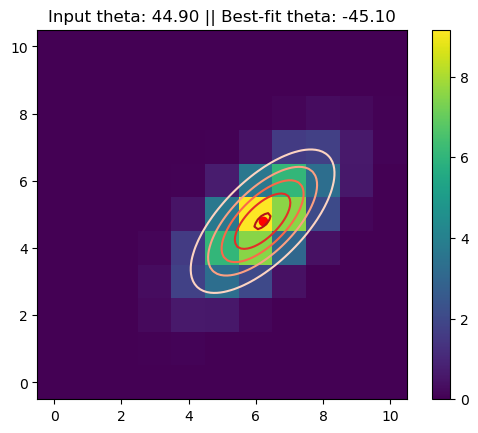

In [102]:
#############################
# TEST THETA ROTATION ANGLE #
#############################

# Generate model
model = GaussianPRF(flux=71.4, x_0=6.2, y_0=4.8, x_fwhm=3.6,
                    y_fwhm=1.6, theta=44.9)
yy, xx = np.mgrid[0:11, 0:11]
data = model(xx, yy)
plt.imshow(data, origin='lower', interpolation='nearest')
plt.colorbar()

# Run fit_2dgaussian_assym
testphot = fit_2dgaussian_assym(data, xypos=[(5., 5.)], fwhm=1.5, fit_shape=9, fix_fwhm=False)
test_tbl = testphot.results
display(test_tbl)

# Best fit mean
x_fit = test_tbl['x_fit'].value[0]
y_fit = test_tbl['y_fit'].value[0]

# Best fit FWHM
x_fwhm = test_tbl['x_fwhm_fit'].value[0]
y_fwhm = test_tbl['y_fwhm_fit'].value[0]

# Best fit standard deviation
x_sigma = x_fwhm / (2. * np.sqrt(2. * np.log(2.)))
y_sigma = y_fwhm / (2. * np.sqrt(2. * np.log(2.)))


# Construct covariance matrix
theta = np.deg2rad(test_tbl['theta_fit'].value[0]) # photutils measures angle from horizontal axis, math measures angle from vertical axis
# print(f'Best fit theta: {np.rad2deg(theta):0.2f} || Input theta: {model.theta.value:0.2f}')
S = np.diag([x_sigma**2, y_sigma**2])
# R = np.array([[np.cos(np.pi/2 - theta), -np.sin(np.pi/2 - theta)], [np.sin(np.pi/2 - theta), np.cos(np.pi/2 - theta)]])
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
newcov = R@S@R.T

# Make and plot contour
N    = 100
X    = np.linspace(0, 10, N)
Y    = np.linspace(0, 10, N)
X, Y = np.meshgrid(X, Y)
pos  = np.dstack((X, Y))
rv   = multivariate_normal([x_fit, y_fit], newcov, allow_singular=True)
Z    = rv.pdf(pos)

plt.contour(X, Y, Z, cmap='Reds', levels=5, origin='lower')
plt.scatter(x_fit, y_fit, marker='o', color='r')
plt.title(f'Input theta: {model.theta.value:0.2f} || Best-fit theta: {np.rad2deg(theta):0.2f}');

## Diagnostic plots

In [ ]:
'''
List of sniff checks that would be good:


PIXEL MAP (values, stdev along wavelength slice)
• Eccentricity
• FWHM_disp
• FWHM_anti_disp
• Dispersion angle

SLICE CHECKS
• Mean eccentricity


CHECK FLAGGED PSFs

'''

In [12]:
# Read in results

results = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool/results/L_psf_fitting_results.fits')
lams = fits.getdata('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/LSF_fromsteph/Lnew_lams.fits')

print(np.shape(results), len(lams))

'''
Params:
• x-centroid
• y-centroid
• FWHM_x (ignore)
• FWHM_y (ignore)
• PSF rotation angle (ignore)
• FWHM along dispersion direction
• FWHM othogonal to dispersion direction
• Fit quality flags (1 means fit is poor)
'''

(56, 8, 103, 110) 56


'\nParams:\n• x-centroid\n• y-centroid\n• FWHM_x (ignore)\n• FWHM_y (ignore)\n• PSF rotation angle (ignore)\n• FWHM along dispersion direction\n• FWHM othogonal to dispersion direction\n• Fit quality flags (1 means fit is poor)\n'

### Eccentricity

True True
(56, 103, 110) 1.0
(103, 110) 1.0


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/2806449922.py:15: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(1. - (b_**2. / a_**2.))
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/2806449922.py:15: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(1. - (b_**2. / a_**2.))


Text(0.5, 1.0, 'Median spot eccentricity')

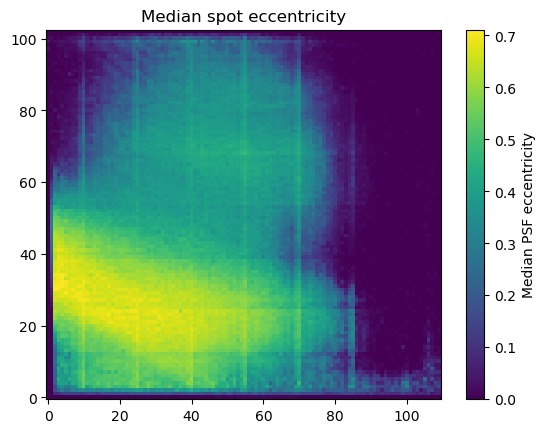

In [301]:


def calc_eccentricity(a, b):
    '''a and b are semi-major and semi-minor axes of ellipse. Can be scalar or same-shape ndarrays.'''
    
#     a_ = np.ma.array(a, mask=~np.isfinite(a)) # Use a mask to mark the NaNs
#     b_ = np.ma.array(b, mask=~np.isfinite(b)) # Use a mask to mark the NaNs

    a_ = np.copy(a)
    b_ = np.copy(b)
    
    a_[~np.isfinite(a_)] = 0.
    b_[~np.isfinite(b_)] = 0.
    
    print(np.all(np.isfinite(a_)), np.all(np.isfinite(b_)))
    
    return np.sqrt(1. - (b_**2. / a_**2.))

# Extract FWHM values
fwhm_d = results[:, 5, :, :] # FWHM along dispersion direction
fwhm_a = results[:, 6, :, :] # FWHM orthogonal to dispersion direction

# Calculate eccentricity
ecc = calc_eccentricity(fwhm_d, fwhm_a) # 56x103x110 array
ecc[~np.isfinite(ecc)] = 0.
print(np.shape(ecc), np.sum(np.isfinite(ecc))/len(np.ravel(ecc)))

# Take nanmedian along wavelength axis
ecc_map = np.nanmean(ecc, axis=0)
print(np.shape(ecc_map), np.sum(np.isfinite(ecc_map))/len(np.ravel(ecc_map)))

# Visualize

plt.imshow(ecc_map, origin='lower')
plt.colorbar(shrink=1., label='Median PSF eccentricity')
plt.title('Median spot eccentricity')

### FWHM

/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_99375/3505048028.py:6: RuntimeWarning: All-NaN slice encountered
  fwhm_d_map = np.nanmedian(fwhm_d, axis=0)
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_99375/3505048028.py:7: RuntimeWarning: All-NaN slice encountered
  fwhm_a_map = np.nanmedian(fwhm_a, axis=0)


Text(0, 0.5, 'Avg FWHM ($\\mu$m)')

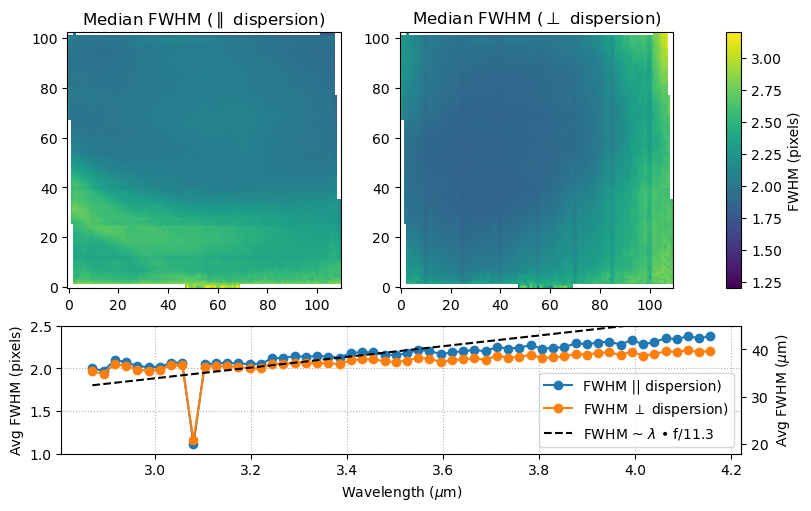

In [44]:
# Read in
fwhm_d = results[:, 5, :, :] # FWHM along dispersion direction
fwhm_a = results[:, 6, :, :] # FWHM orthogonal to dispersion direction

# Nanmedian along wavelength axis
fwhm_d_map = np.nanmedian(fwhm_d, axis=0)
fwhm_a_map = np.nanmedian(fwhm_a, axis=0)

# Nanmean along pixel axes
fwhm_d_trace = np.array([np.nanmean(fwhm_d[i,:,:]) for i in range(0, np.shape(fwhm_d)[0])])
fwhm_a_trace = np.array([np.nanmean(fwhm_a[i,:,:]) for i in range(0, np.shape(fwhm_a)[0])])
# fwhm_d_trace_med = np.array([np.nanmedian(fwhm_d[i,:,:]) for i in range(0, np.shape(fwhm_d)[0])]) # this is the same
# fwhm_a_trace_med = np.array([np.nanmedian(fwhm_a[i,:,:]) for i in range(0, np.shape(fwhm_a)[0])])

# Visualize

def pix_to_um(px):
    return 18. * px
def um_to_pix(um):
    return um / 18.

fig = plt.figure(figsize=(8,5), layout="constrained")

# ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=1, rowspan=2)
# ax2 = plt.subplot2grid((3, 2), (0, 1), colspan=1, rowspan=2)
# ax3 = plt.subplot2grid((3, 2), (1, 0), colspan=2, rowspan=1)

# ax1 = plt.subplot(221)
# ax2 = plt.subplot(222)
# ax3 = plt.subplot(212)

# Define axes
gs = GridSpec(3, 13, figure=fig)
ax1 = fig.add_subplot(gs[:2, :6])
ax2 = fig.add_subplot(gs[:2, 6:12])
cax = fig.add_subplot(gs[:2, -1])
ax3 = fig.add_subplot(gs[-1, :])

# imshow maps
m = ax1.imshow(fwhm_d_map, origin='lower', vmin=1.2, vmax=3.2)
ax2.imshow(fwhm_a_map, origin='lower', vmin=1.2, vmax=3.2)
plt.colorbar(mappable=m, cax=cax, label='FWHM (pixels)')

# Show trace plots along wavelength axis
ax3.plot(lams, fwhm_d_trace, marker='o', label='FWHM || dispersion)')
ax3.plot(lams, fwhm_a_trace, marker='o', label='FWHM $\perp$ dispersion)')
# ax3.plot( lams, um_to_pix(lams) * 11.3, color='k', ls='--', label='FWHM ~ $\lambda$ • f/11.3') # theoretical FWHM; lenslets are f/8 in corners, f/11.3 in center
# From Reni:
# The lenslets are f/11.3! Only f/8 at the corners. The spectrograph was never designed to be diffraction-limited, 
# so at the shorter wavelengths you won’t see us matching the diffraction FWHM. We were aiming for ~2 pixel FWHM.


ax3.grid(ls=':')
ax3.legend()
ax3.set_ylim(1.0, 2.5)

axum = ax3.secondary_yaxis('right', functions=(pix_to_um, um_to_pix))

# Do labeling
ax1.set_title(r'Median FWHM ($\parallel$ dispersion)')
ax2.set_title(r'Median FWHM ($\bot$ dispersion)')

ax3.set_ylabel('Avg FWHM (pixels)')
ax3.set_xlabel(r'Wavelength ($\mu$m)')
axum.set_ylabel(r'Avg FWHM ($\mu$m)')

# Save plot
#####

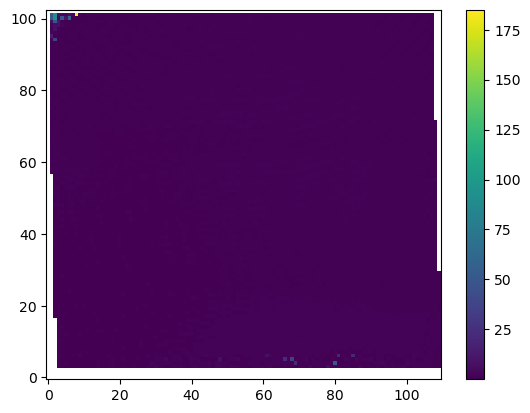

In [37]:
plt.imshow( fwhm_d[9,:,:],origin='lower' )
plt.colorbar()

### Centroid (x,y) shifts

(55, 103, 110) (55, 103, 110)
nan nan
nan nan


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/1110250622.py:7: RuntimeWarning: All-NaN slice encountered
  x_shift_map = np.nanmedian(x_cen_shift, axis=0)
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_7734/1110250622.py:8: RuntimeWarning: All-NaN slice encountered
  y_shift_map = np.nanmedian(y_cen_shift, axis=0)


Text(0.5, 1.0, 'Magnitude of centroid shift between adjacent wavelength slices')

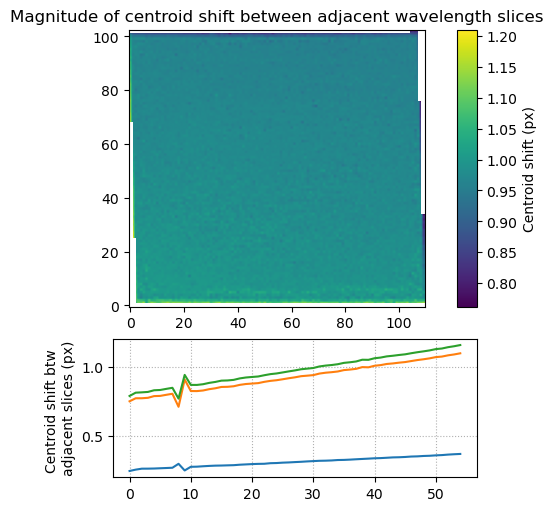

In [352]:
# Calculate centroid shifts between adjacent wavelength slices
x_cen_shift = np.diff(results[:, 0, :, :], axis=0)
y_cen_shift = np.diff(results[:, 1, :, :], axis=0)
print(np.shape(x_cen_shift), np.shape(y_cen_shift))

# Median along wavelength axis
x_shift_map = np.nanmedian(x_cen_shift, axis=0)
y_shift_map = np.nanmedian(y_cen_shift, axis=0)
r_shift_map = np.sqrt(x_shift_map**2 + y_shift_map**2)
# r_shift_map = np.ma.array(r_shift_map, mask=~np.isfinite(r_shift_map))
print(np.min(x_shift_map), np.max(x_shift_map))
print(np.min(y_shift_map), np.max(y_shift_map))

# Average for each wavelength slice
x_shift_trace = np.array([np.nanmean(x_cen_shift[i, :, :]) for i in range(0, np.shape(x_cen_shift)[0])])
y_shift_trace = np.array([np.nanmean(y_cen_shift[i, :, :]) for i in range(0, np.shape(y_cen_shift)[0])])
r_shift_trace = np.sqrt(x_shift_trace**2 + y_shift_trace**2)
x_shift_trace_std = np.array([np.nanstd(x_cen_shift[i, :, :]) for i in range(0, np.shape(x_cen_shift)[0])])
y_shift_trace_std = np.array([np.nanstd(y_cen_shift[i, :, :]) for i in range(0, np.shape(y_cen_shift)[0])])

# Visualize
fig = plt.figure(figsize=(5, 5), layout="constrained")

# Define axes
# gs = GridSpec(3, 13, figure=fig)
# ax1 = fig.add_subplot(gs[:2, :6])
# ax2 = fig.add_subplot(gs[:2, 6:12])
# cax = fig.add_subplot(gs[:2, -1])
# ax3 = fig.add_subplot(gs[-1, :])

gs = GridSpec(3, 13, figure=fig)
ax1 = fig.add_subplot(gs[:2, :12])
cax = fig.add_subplot(gs[:2, -1])
ax2 = fig.add_subplot(gs[-1, :])

m = ax1.imshow(r_shift_map, origin='lower')
plt.colorbar(mappable=m, cax=cax, label='Centroid shift (px)')

ax2.plot(x_shift_trace)
ax2.plot(y_shift_trace)
ax2.plot(r_shift_trace)
ax2.grid(ls=':')
ax2.set_ylabel('Centroid shift btw \nadjacent slices (px)')
ax1.set_title('Magnitude of centroid shift between adjacent wavelength slices')

### Playing with wavelength info

In [ ]:
'''
CAMERA = IFS or IMG
OFNAME = '20260114_IFS_UTR_00170.fits'   

MONOWAVE :: wavelength of monochrometer (nm)

'''

## Debugging FWHM anti-disp

In [11]:
from utils import *
from do_psf_fitting import *

(56, 8, 103, 110)
FWHM x: 2.1359051528381063
FWHM y: 2.168176915368398
FWHM ||: 2.1619996968492012
FWHM $\perp$: 2.076072223071865


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_69318/4126940546.py:20: RuntimeWarning: All-NaN slice encountered
  ax[0][0].imshow(np.nanmedian(results[:,2,:,:], axis=0), origin='lower')
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_69318/4126940546.py:21: RuntimeWarning: All-NaN slice encountered
  ax[0][1].imshow(np.nanmedian(results[:,3,:,:], axis=0), origin='lower')
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_69318/4126940546.py:22: RuntimeWarning: All-NaN slice encountered
  ax[1][0].imshow(np.nanmedian(results[:,5,:,:], axis=0), origin='lower')
/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_69318/4126940546.py:23: RuntimeWarning: All-NaN slice encountered
  ax[1][1].imshow(np.nanmedian(results[:,6,:,:], axis=0), origin='lower')


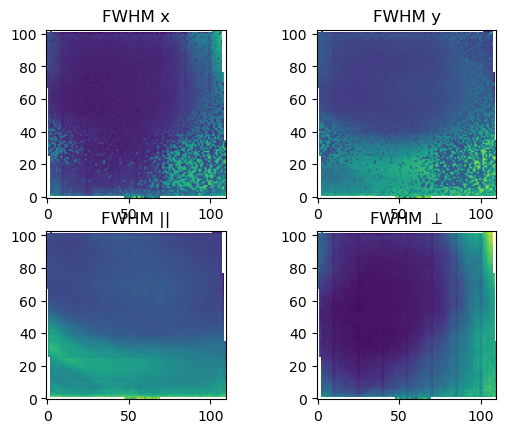

In [17]:
# Read in fitting results

f = '/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool/results/L_psf_fitting_results.fits'
results = fits.getdata(f)
print(np.shape(results))

'''
Params:
• x-centroid
• y-centroid
• FWHM_x (ignore)
• FWHM_y (ignore)
• PSF rotation angle (ignore)
• FWHM along dispersion direction
• FWHM orthogonal to dispersion direction
• Fit quality flags (1 means fit is poor)
''';

fig, ax = plt.subplots(2,2)
ax[0][0].imshow(np.nanmedian(results[:,2,:,:], axis=0), origin='lower')
ax[0][1].imshow(np.nanmedian(results[:,3,:,:], axis=0), origin='lower')
ax[1][0].imshow(np.nanmedian(results[:,5,:,:], axis=0), origin='lower')
ax[1][1].imshow(np.nanmedian(results[:,6,:,:], axis=0), origin='lower')
ax[0][0].set_title('FWHM x')
ax[0][1].set_title('FWHM y')
ax[1][0].set_title('FWHM ||')
ax[1][1].set_title(r'FWHM $\perp$')

print('FWHM x:', np.nanmean(results[:,2,:,:]))
print('FWHM y:', np.nanmean(results[:,3,:,:]))
print('FWHM ||:', np.nanmean(results[:,5,:,:]))
print(r'FWHM $\perp$:', np.nanmean(results[:,6,:,:]))